# Exploratory Data Analysis

This notebook contains EDA of life expectancy and HALE data from WHO, and exploration of mortality indicators from WHO and IHME.
See the data inventory for more information about available indicators.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from utils import (
    decorate, underride, configure_plot_style, AIBM_COLORS, 
    code_to_who_country, code_to_wef_country, write_html_table,
    load_and_inventory, compute_gender_gap, summarize_gap, scatter_plot,
    get_oecd, summarize_years, plot_cdfs, plot_distributions,
    column_name_mapping, oecd_codes
)

configure_plot_style()

# Set cutoff year for temporal analysis (excludes 2020+ to avoid COVID-19 distortions)
cutoff_year = 2019

## WHO HALE data

**Healthy Life Expectancy (HALE) at birth** - The average number of years that a person can expect to live in "full health" by taking into account years lived in less than full health due to disease and/or injury. This is the **target variable** for the analysis. The gender gap (Male HALE - Female HALE) measures the difference in healthy life expectancy between men and women.

**Indicator Code**: WHOSIS_000002  
**Relevance**: Direct measure of the outcome we're trying to explain. Gender differences in HALE reflect the cumulative impact of all mortality and morbidity factors that differentially affect men and women.

Downloaded using the GHO OData API (who_data.py)

https://www.who.int/data/gho/info/gho-odata-api

In [3]:
filename = '../data/who_hale_data.csv'
hale, years = load_and_inventory(filename)

(11100, 10)
['SEX_BTSX' 'SEX_FMLE' 'SEX_MLE']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]


In [4]:
d = {'SEX_BTSX': 'Both', 'SEX_FMLE': 'Female', 'SEX_MLE': 'Male', }
hale['Sex'] = hale['Sex'].replace(d)

In [5]:
hale.head()

,Code,CountryCode,Year,Sex,HALE_Years,HALE_Low,HALE_High,Comments,DataSource,Country
0,AFG,COUNTRY,2000,Both,46.027950,44.939602,47.308578,NaN,NaN,Afghanistan
1,AFG,COUNTRY,2001,Both,46.116121,44.907570,47.033098,NaN,NaN,Afghanistan
2,AFG,COUNTRY,2002,Both,47.184852,46.147952,48.308520,NaN,NaN,Afghanistan
3,AFG,COUNTRY,2003,Both,47.977953,47.016452,48.976006,NaN,NaN,Afghanistan
4,AFG,COUNTRY,2004,Both,48.324761,47.311935,49.325042,NaN,NaN,Afghanistan


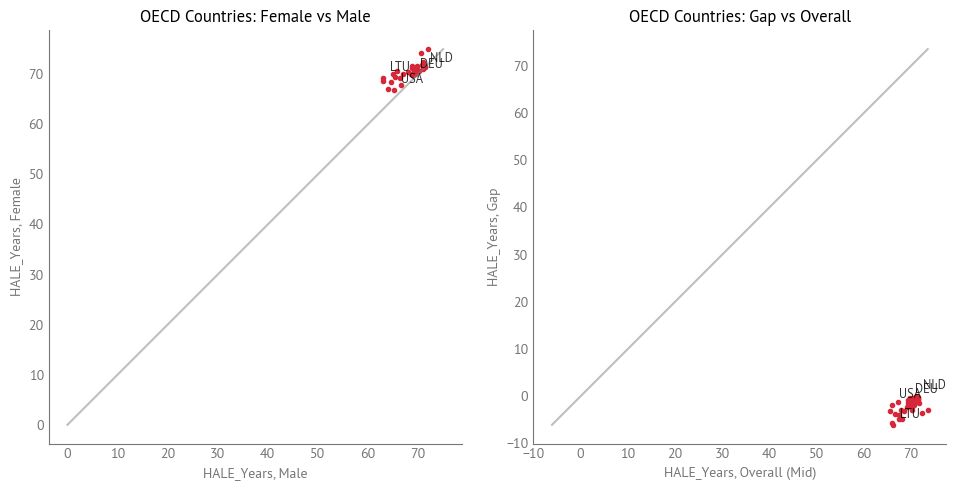

In [6]:
col = 'HALE_Years'
hale_gap = summarize_gap(hale, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/hale_scatter.png', dpi=300, bbox_inches='tight')

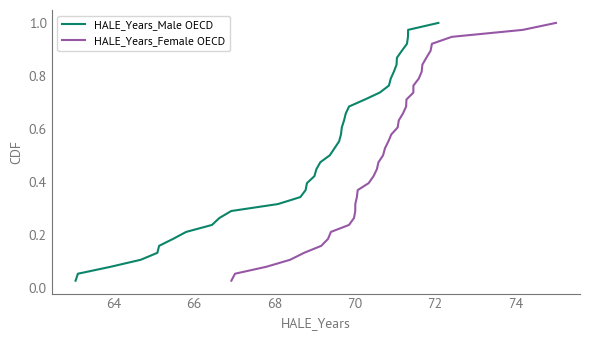

In [7]:
plot_distributions(hale_gap, indicator_name='HALE_Years')
plt.savefig('jb/figs/hale_distributions.png', dpi=300, bbox_inches='tight')

## WHO Life Expectancy data

**Life Expectancy at birth** - The average number of years that a person can expect to live, regardless of health status. This is the **secondary target variable** for the analysis, allowing comparison of which factors explain the gender gap in overall life expectancy versus healthy life expectancy. The gender gap (Female LE - Male LE) measures the difference in life expectancy between women and men.

**Indicator Code**: WHOSIS_000001  
**Relevance**: Life expectancy captures all years lived (healthy and unhealthy), while HALE focuses on healthy years only. Both are calculated from birth, so both should be affected by the same mortality patterns. The relative importance of early-life vs adult mortality may differ between the two outcomes.

Downloaded using the GHO OData API (who_data.py)

https://www.who.int/data/gho/info/gho-odata-api

In [8]:
filename = '../data/who_life_expectancy_data.csv'
le, years = load_and_inventory(filename)

(11100, 10)
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]


In [9]:
d = {'SEX_BTSX': 'Both', 'SEX_FMLE': 'Female', 'SEX_MLE': 'Male', }
le['Sex'] = le['Sex'].replace(d)

In [10]:
le.head()

,Code,CountryCode,Year,Sex,LifeExpectancy_Years,LifeExpectancy_Low,LifeExpectancy_High,Comments,DataSource,Country
0,AFG,COUNTRY,2000,Both sexes,53.823326,52.751923,54.926015,NaN,NaN,Afghanistan
1,AFG,COUNTRY,2001,Both sexes,53.910188,52.857250,54.846553,NaN,NaN,Afghanistan
2,AFG,COUNTRY,2002,Both sexes,55.154478,54.078547,56.222277,NaN,NaN,Afghanistan
3,AFG,COUNTRY,2003,Both sexes,56.085207,55.068934,57.034609,NaN,NaN,Afghanistan
4,AFG,COUNTRY,2004,Both sexes,56.476521,55.550402,57.201137,NaN,NaN,Afghanistan


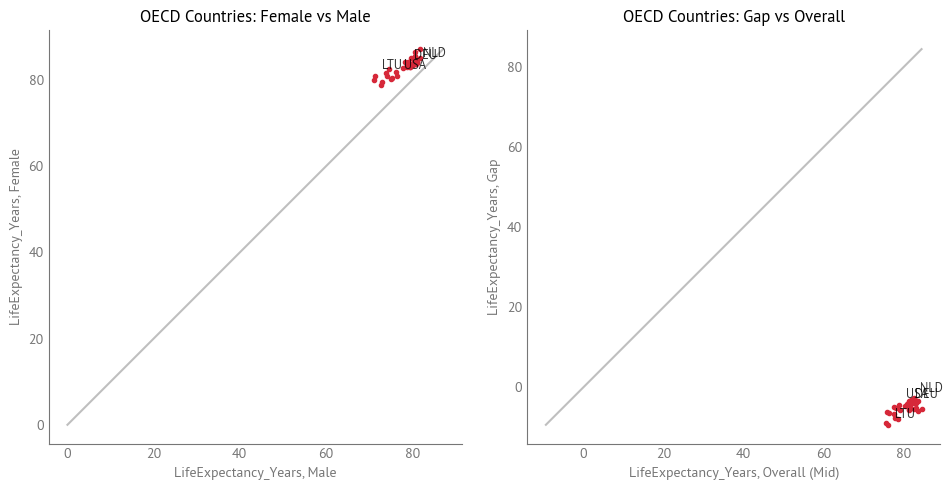

In [11]:
col = 'LifeExpectancy_Years'
le_gap = summarize_gap(le, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/life_expectancy_scatter.png', dpi=300, bbox_inches='tight')

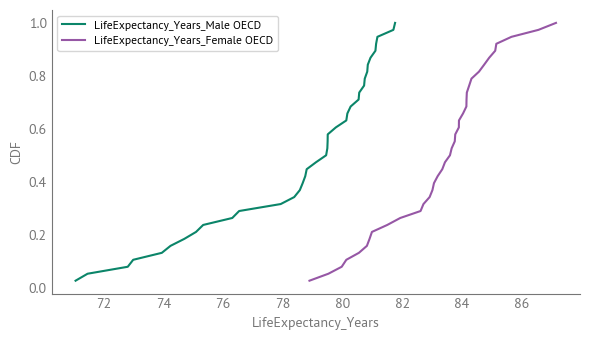

In [12]:
plot_distributions(le_gap, indicator_name='LifeExpectancy_Years')
plt.savefig('jb/figs/life_expectancy_distributions.png', dpi=300, bbox_inches='tight')

## WHO

### Smoking

**Age-standardized current tobacco smoking prevalence (%)** - Percentage of population aged 15+ who currently smoke any tobacco product, age-standardized for cross-country comparison.

**Indicator Code**: M_Est_smk_curr_std  
**Relevance**: Historically, men have had significantly higher smoking rates than women. Smoking is a major contributor to cardiovascular disease, lung cancer, and respiratory diseases. As smoking rates have converged between genders in some countries, the life expectancy gap has narrowed, suggesting smoking is one of the most important modifiable factors contributing to the HALE gender gap.

In [13]:
filename = '../data/who_smoking_data.csv'
smoking, years = load_and_inventory(filename)

(2475, 12)
['Both sexes' 'Female' 'Male']
[nan 'The most recent survey was conducted in 2013. This is a projection.'
 'The most recent survey was conducted in 2011-12. This is a projection.'
 'The most recent survey was conducted in 2012. This is a projection.'
 'The most recent survey was conducted in 2014. This is a projection.']
[2000 2005 2007 2010 2015]


In [14]:
smoking.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,SmokingPrevalence,SmokingPrevalence_Low,SmokingPrevalence_High,Comments,DataSource,Country
0,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2000,Both sexes,22.5,10.5,34.4,NaN,NaN,Afghanistan
1,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2005,Both sexes,17.9,9.6,26.3,NaN,NaN,Afghanistan
2,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2007,Both sexes,16.3,9.4,23.3,NaN,NaN,Afghanistan
3,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2010,Both sexes,14.5,9.6,19.4,NaN,NaN,Afghanistan
4,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2015,Both sexes,11.8,8.0,15.6,NaN,NaN,Afghanistan


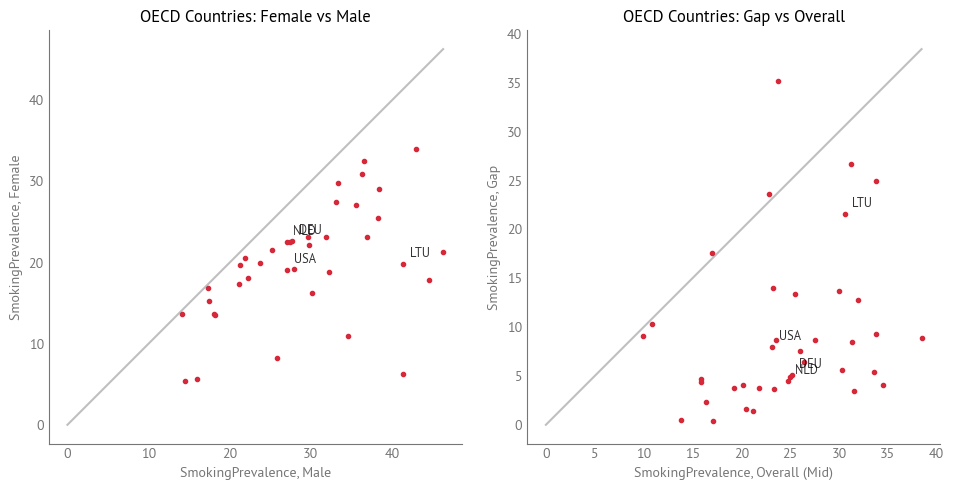

In [15]:
col = 'SmokingPrevalence'
smoking_gap = summarize_gap(smoking, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/smoking_scatter.png', dpi=300, bbox_inches='tight')

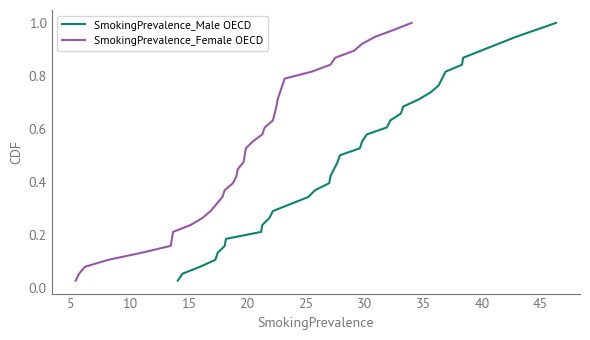

In [16]:
plot_distributions(smoking_gap, indicator_name='SmokingPrevalence')
plt.savefig('jb/figs/smoking_distributions.png', dpi=300, bbox_inches='tight')

### Suicide (WHO - For Reference Only)

**NOTE**: This WHO indicator is kept for reference and comparison, but **the IHME Self-Harm indicator (see below) is used in the model** for better temporal coverage (1990-2023 vs 2000-2021 for WHO).

**Age-standardized suicide rates (per 100,000 population)** - Deaths from intentional self-harm, age-standardized for cross-country comparison.

**Indicator Code**: MH_12  
**Relevance**: Suicide rates are typically higher in men across most countries, directly contributing to the gender gap in mortality. Suicide reflects mental health and social factors that differentially affect men and women, and is strongly linked to mortality.

In [17]:
filename = '../data/who_suicide_rates.csv'
suicide, years = load_and_inventory(filename)

(11100, 12)
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]


In [18]:
suicide.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,SuicideRate,SuicideRate_Low,SuicideRate_High,Comments,DataSource,Country
0,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2000,Both sexes,7.185717,3.764944,12.084243,NaN,NaN,Afghanistan
1,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2001,Both sexes,7.270323,3.817979,12.215665,NaN,NaN,Afghanistan
2,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2002,Both sexes,7.112670,3.821785,11.814730,NaN,NaN,Afghanistan
3,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2003,Both sexes,7.043811,3.856506,12.002093,NaN,NaN,Afghanistan
4,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2004,Both sexes,7.025987,3.889151,12.129586,NaN,NaN,Afghanistan


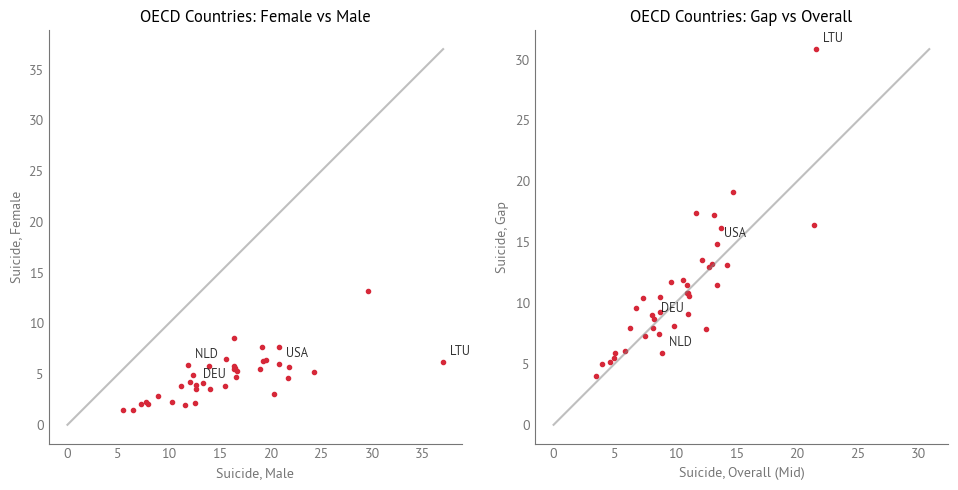

In [19]:
col = 'SuicideRate'
suicide = suicide.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
suicide_gap = summarize_gap(suicide, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/suicide_scatter.png', dpi=300, bbox_inches='tight')

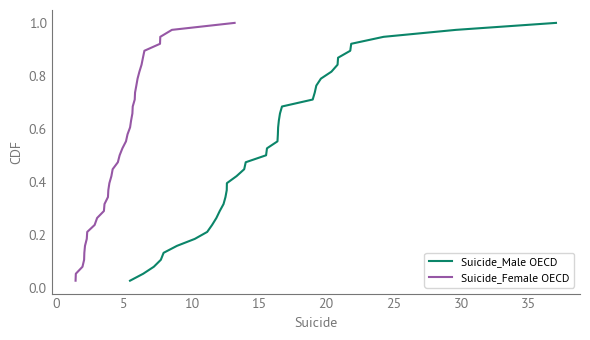

In [20]:
plot_distributions(suicide_gap, indicator_name='Suicide')
plt.savefig('jb/figs/suicide_distributions.png', dpi=300, bbox_inches='tight')

### Alcohol (WHO - For Reference Only)

**NOTE**: This WHO indicator is kept for reference and comparison, but **the IHME Alcohol Use Disorders indicator (see below) is used in the model** for better temporal coverage (1990-2023 vs 2019 only for WHO).

**Alcohol-attributable all-cause deaths per 100,000 (age-standardized)** - Deaths from all causes that are attributable to alcohol consumption, including direct alcohol-related deaths and alcohol-attributable deaths from other causes (e.g., accidents, liver disease).

**Indicator Code**: SA_0000001832  
**Relevance**: Men typically have higher rates of alcohol consumption and alcohol-related diseases. Alcohol contributes to liver disease, accidents, and various health conditions, directly impacting mortality. Age-standardized rates match HALE methodology for cross-country comparison.

In [21]:
filename = '../data/who_alcohol_death_rates.csv'
alcohol, years = load_and_inventory(filename)

(540, 12)
['Both sexes' 'Female' 'Male']
[nan]
[2019]


In [22]:
alcohol.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,AlcoholDeathRate,AlcoholDeathRate_Low,AlcoholDeathRate_High,Comments,DataSource,Country
0,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AFG,COUNTRY,2019,Both sexes,4.949863,4.002665,6.983689,NaN,NaN,Afghanistan
1,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AFG,COUNTRY,2019,Female,4.002300,2.527392,6.215428,NaN,NaN,Afghanistan
2,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AFG,COUNTRY,2019,Male,5.914343,4.479561,9.296961,NaN,NaN,Afghanistan
3,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AGO,COUNTRY,2019,Both sexes,88.707178,63.949144,114.463780,NaN,NaN,Angola
4,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AGO,COUNTRY,2019,Female,34.885563,26.543712,47.578170,NaN,NaN,Angola


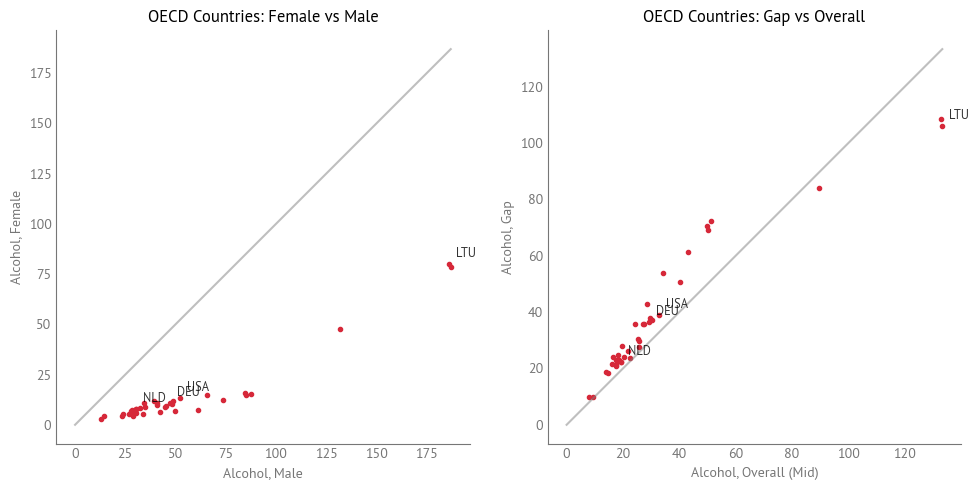

In [23]:
col = 'AlcoholDeathRate'
alcohol = alcohol.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
alcohol_gap = summarize_gap(alcohol, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/alcohol_who_scatter.png', dpi=300, bbox_inches='tight')

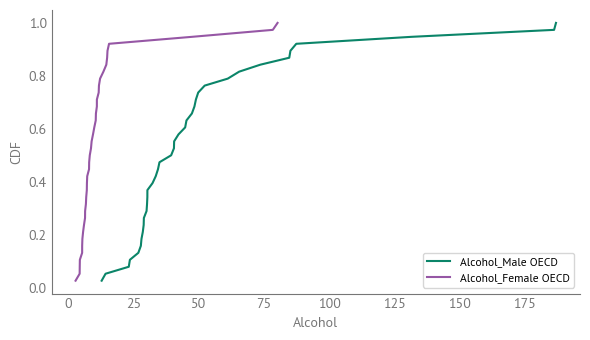

In [24]:
plot_distributions(alcohol_gap, indicator_name='Alcohol')
plt.savefig('jb/figs/alcohol_who_distributions.png', dpi=300, bbox_inches='tight')

### Poison (WHO - For Reference Only)

**NOTE**: This WHO indicator is kept for reference and comparison, but **not used in the model**. The IHME Drug Use Disorders indicator (see below) is used instead, as it provides better temporal coverage (1990-2023 vs 2000-2021 for WHO) and captures drug overdose deaths more comprehensively.

**Mortality rate attributed to unintentional poisoning (per 100,000 population)** - Deaths from accidental poisonings from chemicals, drugs, and other substances.

**Indicator Code**: SDGPOISON  
**Relevance**: Men often have higher rates of accidental deaths, including poisonings. This reflects occupational hazards and risk-taking behaviors that contribute to the gender gap in mortality. Has excellent temporal coverage (2000-2021) and country coverage (196 countries).

In [25]:
filename = '../data/who_poisoning_rates.csv'
poison, years = load_and_inventory(filename)

(11100, 12)
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]


In [26]:
poison.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,PoisoningRate,PoisoningRate_Low,PoisoningRate_High,Comments,DataSource,Country
0,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2000,Both sexes,3.272761,1.091069,6.816218,NaN,NaN,Afghanistan
1,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2001,Both sexes,3.351724,1.157869,6.926548,NaN,NaN,Afghanistan
2,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2002,Both sexes,3.038659,0.946774,6.704357,NaN,NaN,Afghanistan
3,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2003,Both sexes,3.689834,1.521052,7.401055,NaN,NaN,Afghanistan
4,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2004,Both sexes,3.681742,1.573983,7.347575,NaN,NaN,Afghanistan


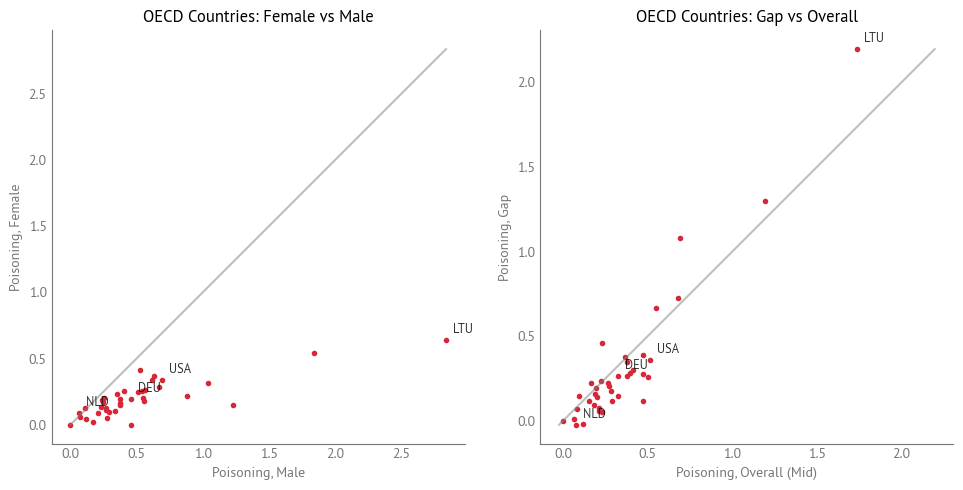

In [27]:
col = 'PoisoningRate'
poison = poison.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
poison_gap = summarize_gap(poison, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/poisoning_scatter.png', dpi=300, bbox_inches='tight')

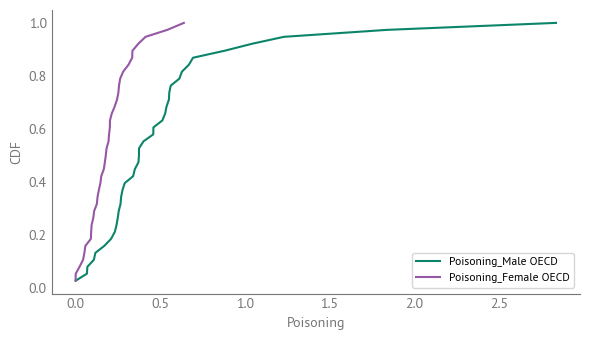

In [28]:
plot_distributions(poison_gap, indicator_name='Poisoning')
plt.savefig('jb/figs/poisoning_distributions.png', dpi=300, bbox_inches='tight')

### Traffic (WHO - For Reference Only)

**NOTE**: This WHO indicator is kept for reference and comparison, but **the IHME Road Injuries indicator (see below) is used in the model** for much better temporal coverage (1990-2023 vs 2019 only for WHO).

**Road traffic crash deaths, age-standardized death rates (15+), per 100,000 population** - Deaths from road traffic accidents, age-standardized for ages 15+.

**Indicator Code**: SA_0000001459  
**Relevance**: Road traffic deaths are typically 2-4 times higher in men across most countries, making it a major contributor to the gender gap in mortality. Reflects higher exposure to driving (including occupational exposure), occupational hazards, and potentially risk-taking behaviors. Age-standardized rates for ages 15+ match HALE methodology.

In [29]:
filename = '../data/who_road_traffic_death_rates.csv'
traffic, years = load_and_inventory(filename)

(540, 12)
['Both sexes' 'Female' 'Male']
[nan]
[2019]


In [30]:
traffic.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,RoadTrafficDeathRate,RoadTrafficDeathRate_Low,RoadTrafficDeathRate_High,Comments,DataSource,Country
0,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AFG,COUNTRY,2019,Both sexes,19.806936,NaN,NaN,NaN,NaN,Afghanistan
1,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AFG,COUNTRY,2019,Female,8.323253,NaN,NaN,NaN,NaN,Afghanistan
2,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AFG,COUNTRY,2019,Male,30.823815,NaN,NaN,NaN,NaN,Afghanistan
3,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AGO,COUNTRY,2019,Both sexes,30.060828,NaN,NaN,NaN,NaN,Angola
4,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AGO,COUNTRY,2019,Female,18.692964,NaN,NaN,NaN,NaN,Angola


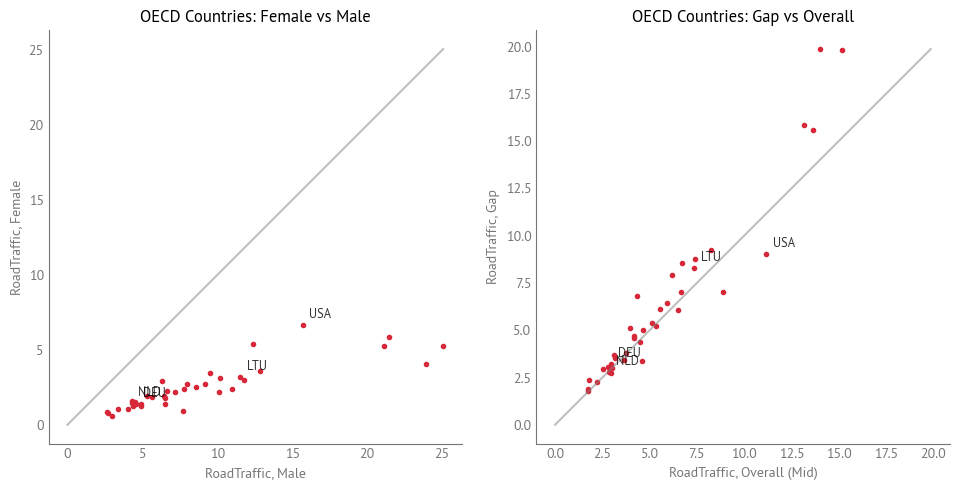

In [31]:
col = 'RoadTrafficDeathRate'
traffic = traffic.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
traffic_gap = summarize_gap(traffic, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/road_traffic_who_scatter.png', dpi=300, bbox_inches='tight')

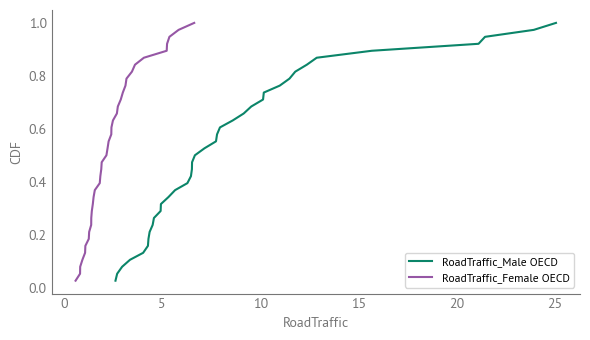

In [32]:
plot_distributions(traffic_gap, indicator_name='RoadTraffic')
plt.savefig('jb/figs/road_traffic_who_distributions.png', dpi=300, bbox_inches='tight')

### Maternal mortality

**Maternal mortality ratio (per 100,000 live births)** - Deaths of women during pregnancy, childbirth, or within 42 days of termination of pregnancy, per 100,000 live births.

**Indicator Code**: MDG_0000000026  
**Relevance**: Critical for understanding cases where the HALE gender gap is small due to high female mortality, especially in lower-income countries. High maternal mortality can significantly reduce the HALE gender gap by lowering female life expectancy. Inherently female-specific, so only female values are used in analysis.

In [33]:
filename = '../data/who_maternal_mortality_ratio.csv'
maternal, years = load_and_inventory(filename)

(3900, 12)
['Female']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]


In [34]:
maternal.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,MaternalMortalityRatio,MaternalMortalityRatio_Low,MaternalMortalityRatio_High,Comments,DataSource,Country
0,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2000,Female,1371.645908,937.495878,1828.321863,NaN,NaN,Afghanistan
1,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2001,Female,1310.954923,906.872935,1734.166876,NaN,NaN,Afghanistan
2,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2002,Female,1262.516681,884.408915,1652.739115,NaN,NaN,Afghanistan
3,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2003,Female,1201.381450,857.173518,1567.186347,NaN,NaN,Afghanistan
4,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2004,Female,1166.469374,849.256289,1515.271527,NaN,NaN,Afghanistan


In [35]:
col = 'MaternalMortalityRatio'
maternal = maternal.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
maternal_gap = summarize_gap(maternal, col, sexes=['Female'], cutoff_year=cutoff_year)
plt.savefig('jb/figs/maternal_mortality_scatter.png', dpi=300, bbox_inches='tight')

<Figure size 600x350 with 0 Axes>

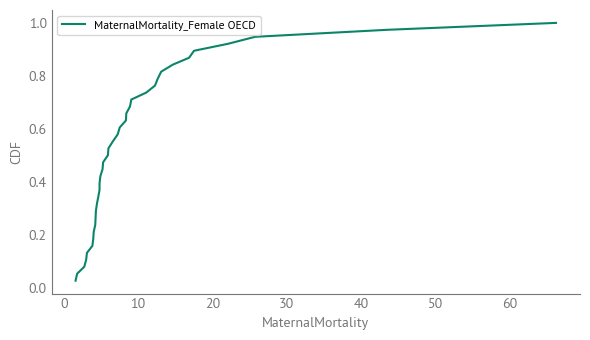

In [36]:
plot_distributions(maternal_gap, indicator_name='MaternalMortality')
plt.savefig('jb/figs/maternal_mortality_distributions.png', dpi=300, bbox_inches='tight')

### Homicide (WHO - For Reference Only)

**NOTE**: This WHO indicator is kept for reference and comparison, but **the IHME Interpersonal Violence indicator (see below) is used in the model** for better temporal coverage (1990-2023 vs 2000-2021 for WHO).

**Estimates of rates of homicides per 100,000 population** - Deaths from intentional homicide, including estimates with confidence intervals.

**Indicator Code**: VIOLENCE_HOMICIDERATE  
**Relevance**: Homicide rates are typically much higher in men across most countries, making it a major contributor to the gender gap in mortality. Homicide reflects violence, conflict, and social factors that differentially affect men and women. Has excellent temporal coverage (2000-2021) and country coverage (196 countries).

In [37]:
filename = '../data/who_homicide_rates.csv'
homicide, years = load_and_inventory(filename)

(11100, 12)
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]


In [38]:
homicide.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,HomicideRate,HomicideRate_Low,HomicideRate_High,Comments,DataSource,Country
0,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2000,Both sexes,10.433863,5.581236,16.844870,NaN,NaN,Afghanistan
1,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2001,Both sexes,10.617865,5.678589,17.162430,NaN,NaN,Afghanistan
2,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2002,Both sexes,10.953708,6.568415,16.902796,NaN,NaN,Afghanistan
3,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2003,Both sexes,10.781847,6.539156,16.757218,NaN,NaN,Afghanistan
4,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2004,Both sexes,10.135798,5.742813,16.420052,NaN,NaN,Afghanistan


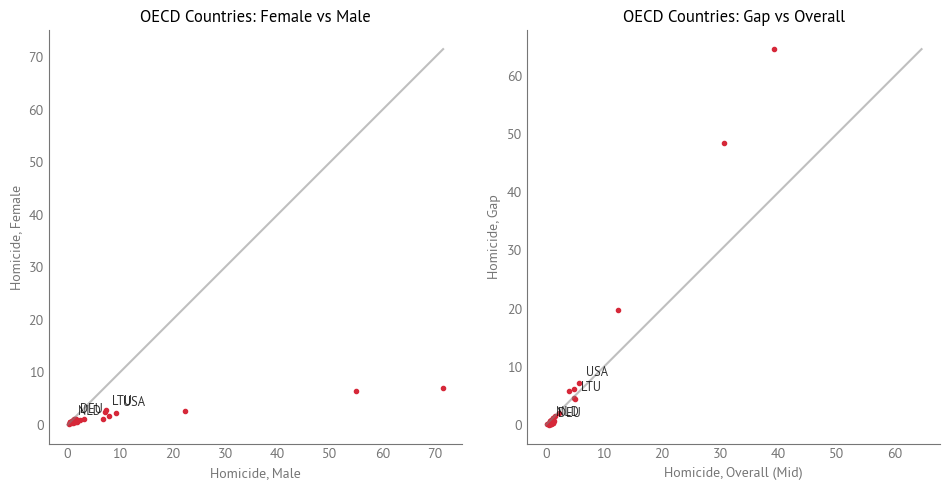

In [39]:
col = 'HomicideRate'
homicide = homicide.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
homicide_gap = summarize_gap(homicide, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/homicide_who_scatter.png', dpi=300, bbox_inches='tight')

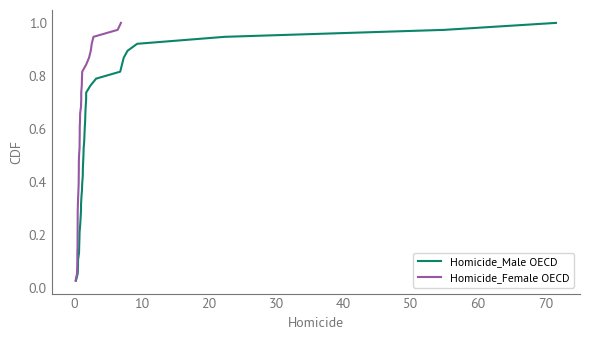

In [40]:
plot_distributions(homicide_gap, indicator_name='Homicide')
plt.savefig('jb/figs/homicide_who_distributions.png', dpi=300, bbox_inches='tight')

### Intimate Partner Violence

**Proportion of ever-partnered women and girls aged 15-49 years subjected to physical and/or sexual violence by a current or former intimate partner in the previous 12 months (%)** - Prevalence indicator measuring the percentage of women experiencing intimate partner violence.

**Indicator Code**: SDGIPV  
**Relevance**: Note: This is a **prevalence indicator** (percentage), not a direct death rate. IPV affects women's health indirectly through mental health impacts, injuries, and other health consequences. It may contribute to the gender gap in HALE through its effects on women's physical and mental health, though the relationship is complex and indirect. Inherently female-specific, so only female values are used in analysis.

In [41]:
filename = '../data/who_ipv_prevalence.csv'
ipv, years = load_and_inventory(filename)

(558, 12)
['Female']
['DHS '
 'calculated by FRA based on available country data from the 2012 FRA Violence against women: an EU-wide Survey  Women aged 18-74; definition of physical and sexual violence differs from the standard'
 'Violence against Women Survey 2015 '
 'Calculated by UNFPA based on available country data from the Violence against Women Survey 2015 UNECE methodology; women aged 15+'
 'PAHO 2018 publication Intimate Partner Violence against Women in the Americas: calculated by PAHO based on available country data from the Encuesta de Prevalencia y Caracteristicas de la Violencia contra las Mujeres 2016 ~ENDIREH methodology; women aged 15+; definition of sexual violence differs from the standard'
 'MICS ' 'DHS Currently married'
 'DHS Refers to currently married girls and women'
 'The Cook Islands Family Health and Safety Study '
 'The Cook Islands Family Health and Safety Study Based on definition used in the WHO multi-country study on women’s health and domestic violenc

In [42]:
ipv.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,IPVPrevalence,IPVPrevalence_Low,IPVPrevalence_High,Comments,DataSource,Country
18,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,49.1,NaN,NaN,DHS,NaN,Afghanistan
19,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,45.2,NaN,NaN,DHS,NaN,Afghanistan
20,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,51.9,NaN,NaN,DHS,NaN,Afghanistan
21,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,49.3,NaN,NaN,DHS,NaN,Afghanistan
22,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,48.6,NaN,NaN,DHS,NaN,Afghanistan


In [43]:
col = 'IPVPrevalence'
ipv_gap = summarize_gap(ipv, col, sexes=['Female'], cutoff_year=cutoff_year)
plt.savefig('jb/figs/ipv_scatter.png', dpi=300, bbox_inches='tight')

<Figure size 600x350 with 0 Axes>

/home/downey/EqualityWEF/HALE/utils.py:1723: UserWarning: Missing 12 OECD countries in data: ['AUS', 'CAN', 'CHE', 'CHL', 'CRI', 'ISL', 'ISR', 'JPN', 'KOR', 'NOR', 'NZL', 'USA']
  warnings.warn(


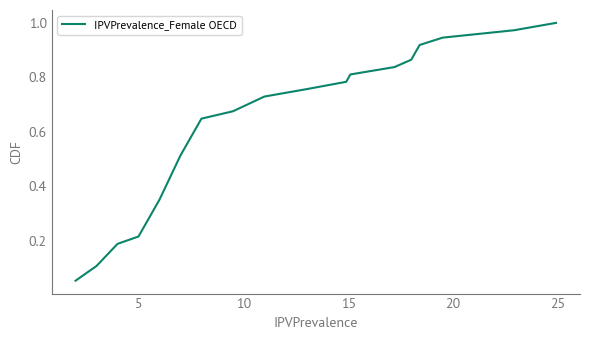

In [44]:
plot_distributions(ipv_gap, indicator_name='IPVPrevalence')
plt.savefig('jb/figs/ipv_distributions.png', dpi=300, bbox_inches='tight')

### Under five mortality rate (WHO - For Reference Only)

**NOTE**: This WHO indicator is kept for reference and comparison, but **the IHME All-Cause Deaths Under 5 Years indicator (see below) is used in the model** for better temporal coverage (1990-2023 vs 1932-2023 for WHO, but IHME provides consistent methodology with other IHME indicators).

**Under-five mortality rate (probability of dying by age 5 per 1000 live births)** - Deaths of children under age 5 per 1,000 live births, with gender breakdowns.

**Indicator Code**: MDG_0000000007  
**Relevance**: HALE is calculated from birth, so under-five mortality directly affects HALE calculations. If child mortality differs by gender, it directly contributes to the HALE gender gap. Infant mortality is typically higher in males (biological vulnerability + some behavioral factors). More important in lower-income countries with high child mortality. Note: MDG_0000000007 chosen over u5mr for better data quality when filtered for sex dimension.

In [45]:
filename = '../data/who_u5mr.csv'
u5mr, years = load_and_inventory(filename)

(22600, 12)
['Both sexes' 'Female' 'Male']
[nan
 'Some UN IGME indicators are calculated using population and live birth numbers from the World Population Prospects: The 2024 revision (WPP). The WPP numbers for Cyprus refer to the entire country. However, the underlying data used to calculate mortality rates estimates, provided by the Health Monitoring Unit of the Cyprus Ministry of Health, cover only the government-controlled areas, whereas according to Eurostat, the number of live births in 2023 was 10,295 (https://ec.europa.eu/eurostat/databrowser/view/tps00204/), the population on 1 January 2023 was 920,701 (https://ec.europa.eu/eurostat/databrowser/view/tps00001/), the population under 5 was 49,326,  adolescent population was 99,207 and the number of women of reproductive age was 235,268 (https://doi.org/10.2908/DEMO_PJAN).'
 'The UN IGME estimates are not the official statistics of India. The Sample Registration System (SRS) of ORGI is the official data source of India for all mo

In [46]:
u5mr.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,U5MR,U5MR_Low,U5MR_High,Comments,DataSource,Country
0,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,131.657158,122.050144,142.254414,NaN,NaN,Afghanistan
1,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,146.404320,129.690344,164.793287,NaN,NaN,Afghanistan
2,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,116.604951,101.901270,133.012767,NaN,NaN,Afghanistan
3,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,139.669993,126.880951,153.782482,NaN,NaN,Afghanistan
4,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,92.831046,79.709380,107.613673,NaN,NaN,Afghanistan


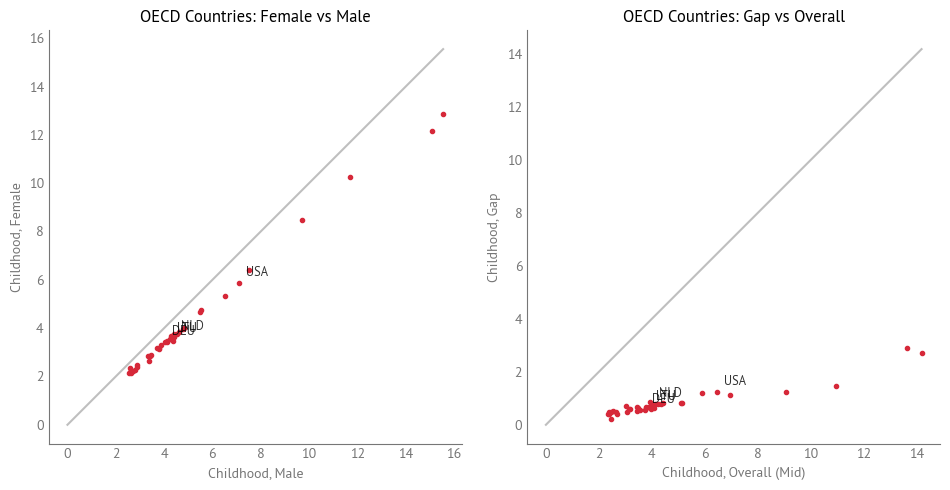

In [47]:
col = 'U5MR'
u5mr = u5mr.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
u5mr_gap = summarize_gap(u5mr, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/u5mr_scatter.png', dpi=300, bbox_inches='tight')

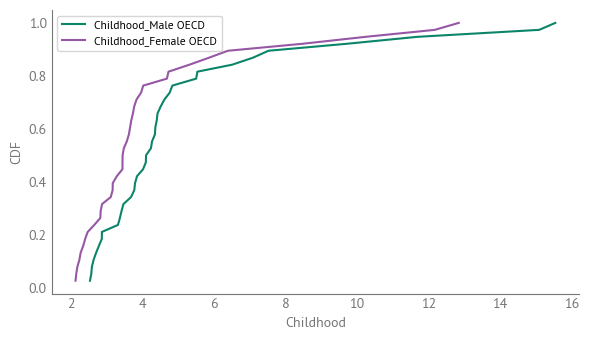

In [48]:
plot_distributions(u5mr_gap, indicator_name='Childhood')
plt.savefig('jb/figs/u5mr_distributions.png', dpi=300, bbox_inches='tight')

### Cardiovascular Disease

**Age-standardized cardiovascular disease death rates (per 100,000)** - Deaths from cardiovascular diseases (heart disease, stroke, etc.), age-standardized for cross-country comparison.

**Indicator Code**: Multiple codes tried (WHS2_161, etc.) - see `who_data.py` for implementation details  
**Relevance**: Men typically have higher rates of cardiovascular disease and heart attacks, contributing significantly to the gender gap in mortality. Risk factors include smoking, diet, and potentially biological differences. May capture effects of smoking and other risk factors. Age-standardized rates match HALE methodology.

In [49]:
filename = '../data/who_cardiovascular_death_rates.csv'
cardio, years = load_and_inventory(filename)

(573, 12)
['Both sexes' 'Female' 'Male']
[nan]
[2004]


In [50]:
# Rename DeathRate to CardioDeathRate to avoid ambiguity
cardio = cardio.rename(columns={'DeathRate': 'CardioDeathRate'})
cardio.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,CardioDeathRate,DeathRate_Low,DeathRate_High,Comments,DataSource,Country
0,SA_0000001444,NaN,AFG,COUNTRY,2004,Both sexes,366.9,NaN,NaN,NaN,NaN,Afghanistan
1,SA_0000001444,NaN,AFG,COUNTRY,2004,Female,282.9,NaN,NaN,NaN,NaN,Afghanistan
2,SA_0000001444,NaN,AFG,COUNTRY,2004,Male,447.4,NaN,NaN,NaN,NaN,Afghanistan
3,SA_0000001444,NaN,AGO,COUNTRY,2004,Both sexes,142.4,NaN,NaN,NaN,NaN,Angola
4,SA_0000001444,NaN,AGO,COUNTRY,2004,Female,111.0,NaN,NaN,NaN,NaN,Angola


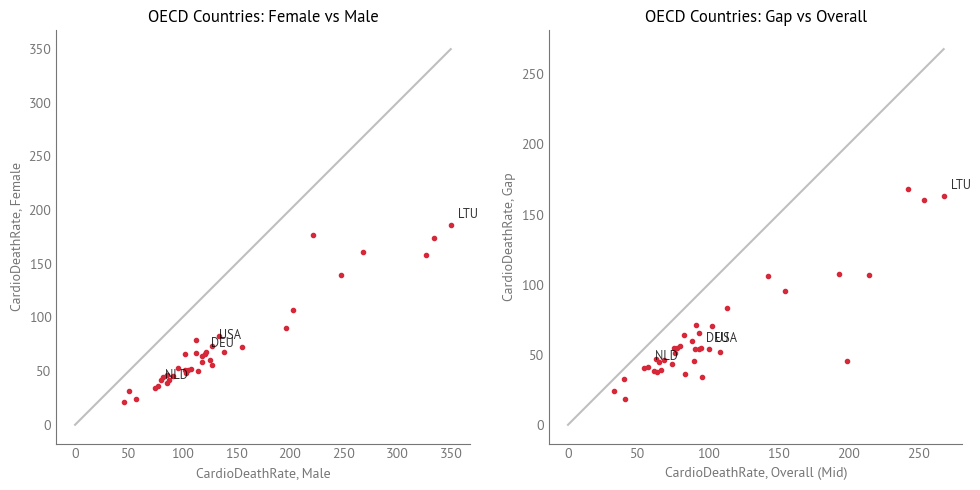

In [51]:
col = 'CardioDeathRate'
cardio_gap = summarize_gap(cardio, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/cardiovascular_who_scatter.png', dpi=300, bbox_inches='tight')

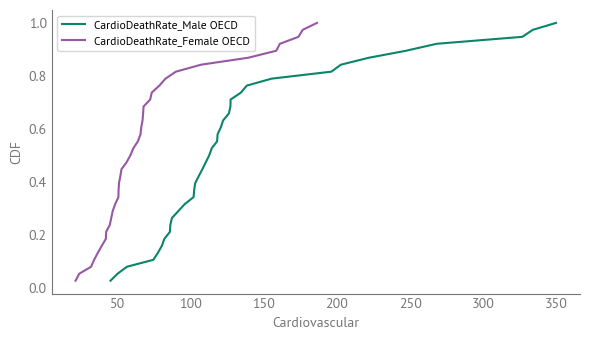

In [52]:
plot_distributions(cardio_gap, indicator_name='Cardiovascular')
plt.savefig('jb/figs/cardiovascular_who_distributions.png', dpi=300, bbox_inches='tight')

### Diabetes

**Age-standardized death rates, diabetes mellitus (per 100,000)** - Deaths from diabetes, age-standardized for cross-country comparison.

**Indicator Code**: SA_0000001440  
**Relevance**: Diabetes is a chronic condition that can contribute to the gender gap in mortality, though the relationship may vary by country and healthcare access. Age-standardized rates match HALE methodology. **Limitation**: Only has data for 2004 (similar to cardiovascular disease indicators), which limits temporal analysis but provides a good cross-sectional snapshot.

In [53]:
filename = '../data/who_diabetes_death_rates.csv'
diabetes, years = load_and_inventory(filename)

(573, 12)
['Both sexes' 'Female' 'Male']
[nan]
[2004]


In [54]:
diabetes.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,DiabetesDeathRate,DiabetesDeathRate_Low,DiabetesDeathRate_High,Comments,DataSource,Country
0,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AFG,COUNTRY,2004,Both sexes,29.3,NaN,NaN,NaN,NaN,Afghanistan
1,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AFG,COUNTRY,2004,Female,30.9,NaN,NaN,NaN,NaN,Afghanistan
2,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AFG,COUNTRY,2004,Male,27.5,NaN,NaN,NaN,NaN,Afghanistan
3,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AGO,COUNTRY,2004,Both sexes,67.6,NaN,NaN,NaN,NaN,Angola
4,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AGO,COUNTRY,2004,Female,74.2,NaN,NaN,NaN,NaN,Angola


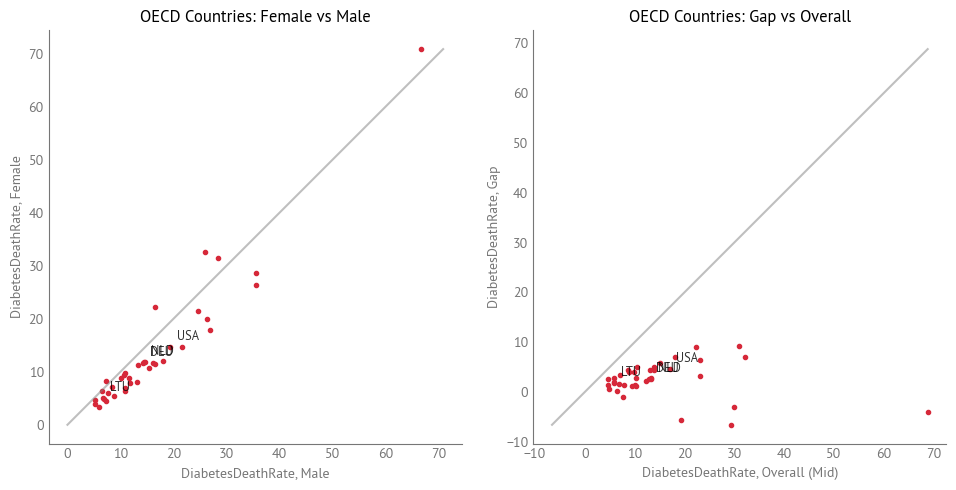

In [55]:
col = 'DiabetesDeathRate'
diabetes_gap = summarize_gap(diabetes, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/diabetes_who_scatter.png', dpi=300, bbox_inches='tight')

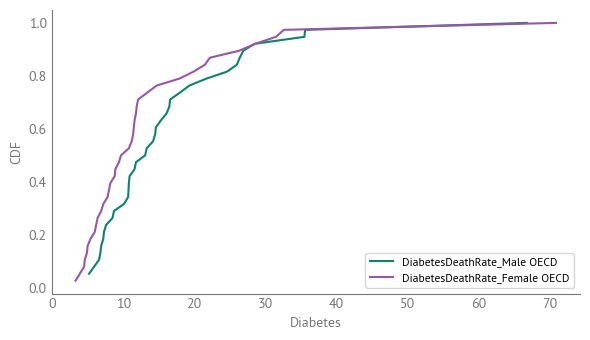

In [56]:
plot_distributions(diabetes_gap, indicator_name='Diabetes')
plt.savefig('jb/figs/diabetes_who_distributions.png', dpi=300, bbox_inches='tight')

### NCD Mortality (30-70 years)

**Probability (%) of dying between age 30 and exact age 70 from any of cardiovascular disease, cancer, diabetes, or chronic respiratory disease** - Combined non-communicable disease mortality indicator.

**Indicator Code**: NCDMORT3070  
**Relevance**: Combines multiple causes of death (cardiovascular disease, cancer, diabetes, chronic respiratory disease), so it's less specific than individual cause indicators. However, it has much better temporal coverage (2000-2021) than diabetes-specific indicators (which only have 2004 data). This makes it useful for model comparison - trading off specificity for temporal coverage. The combined indicator may capture overall NCD mortality patterns that contribute to the HALE gender gap.

In [57]:
filename = '../data/who_ncd_mortality_30_70.csv'
ncdmort, years = load_and_inventory(filename)

(11100, 12)
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]


In [58]:
ncdmort.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,NCDMortality30_70,NCDMortality30_70_Low,NCDMortality30_70_High,Comments,DataSource,Country
0,NCDMORT3070,Probability (%) of dying between age 30 and ex...,AFG,COUNTRY,2000,Both sexes,43.2,25.6,60.0,NaN,NaN,Afghanistan
1,NCDMORT3070,Probability (%) of dying between age 30 and ex...,AFG,COUNTRY,2001,Both sexes,43.5,25.8,60.3,NaN,NaN,Afghanistan
2,NCDMORT3070,Probability (%) of dying between age 30 and ex...,AFG,COUNTRY,2002,Both sexes,43.1,25.7,60.2,NaN,NaN,Afghanistan
3,NCDMORT3070,Probability (%) of dying between age 30 and ex...,AFG,COUNTRY,2003,Both sexes,42.5,25.6,60.1,NaN,NaN,Afghanistan
4,NCDMORT3070,Probability (%) of dying between age 30 and ex...,AFG,COUNTRY,2004,Both sexes,42.3,25.6,60.0,NaN,NaN,Afghanistan


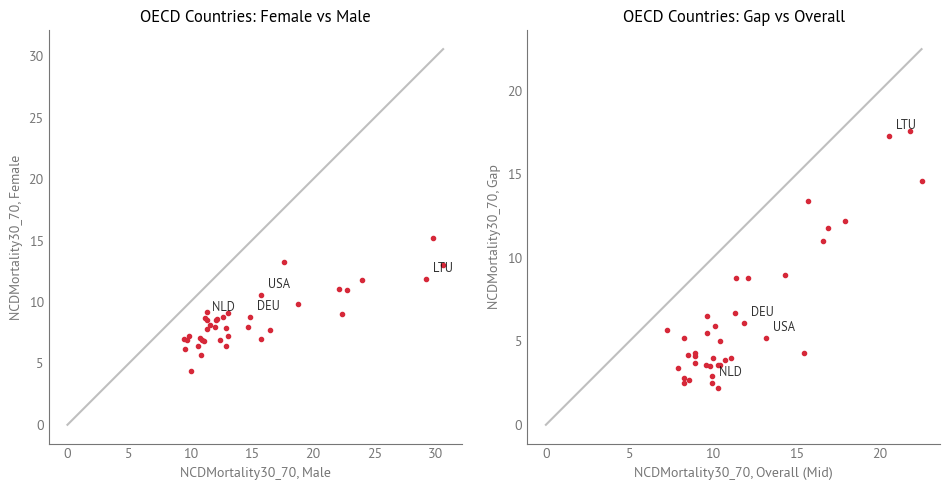

In [59]:
col = 'NCDMortality30_70'
ncdmort_gap = summarize_gap(ncdmort, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/ncd_mortality_scatter.png', dpi=300, bbox_inches='tight')

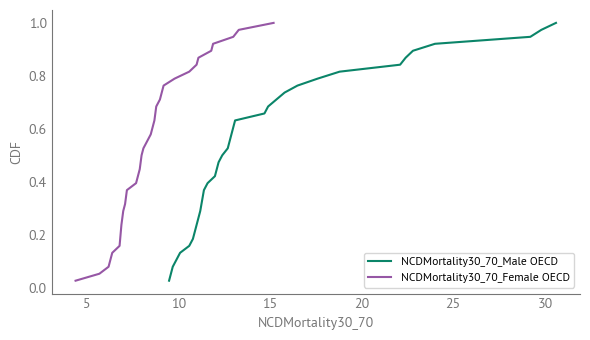

In [60]:
plot_distributions(ncdmort_gap, indicator_name='NCDMortality30_70')
plt.savefig('jb/figs/ncd_mortality_distributions.png', dpi=300, bbox_inches='tight')

## IHME

### Drug Use Disorders (IHME) - USED IN MODEL

**Drug use disorder death rates (per 100,000 population)** - Deaths from drug use disorders, including overdoses, from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Drug overdoses, particularly opioid overdoses, are a major cause of death in some OECD countries (especially the US) and may contribute significantly to the HALE gender gap. **This IHME indicator is used in the model** instead of WHO Poisoning because it provides better temporal coverage (1990-2023 vs 2000-2021 for WHO) and captures drug overdose deaths more comprehensively. This indicator captures overdose deaths that may not be fully captured in the WHO poisoning indicator. Data includes separate male and female values, allowing for gender gap analysis.

In [61]:
def load_ihme_indicator(filename_male, filename_female, value_col_name, indicator_code, indicator_name):
    """
    Load IHME indicator data from separate male and female files and convert to WHO-compatible format.
    
    Converts IHME CSV format (Location=country name, Sex="Male"/"Female") to WHO format
    (Country=country code, Sex="Male"/"Female", etc.). Filters to 2000-2019.
    
    Parameters
    ----------
    filename_male : str
        Path to the IHME CSV file with male data.
    filename_female : str
        Path to the IHME CSV file with female data.
    value_col_name : str
        Name for the value column (e.g., 'DrugDisorderDeathRate', 'DiabetesDeathRate').
    indicator_code : str
        Indicator code for the IHME indicator (e.g., 'IHME_DRUG_DISORDERS', 'IHME_DIABETES_TYPE2').
    indicator_name : str
        Human-readable indicator name (e.g., 'Drug use disorders, death rate per 100,000').
        
    Returns
    -------
    df : pandas.DataFrame
        DataFrame in WHO-compatible format with columns: IndicatorCode, IndicatorName,
        Code, CountryCode, Year, Sex, value_col_name, value_col_name_Low, 
        value_col_name_High, Country.
    years : numpy.ndarray
        Array of unique years present in the filtered dataset.
    """
    # Create reverse mapping from country name to code
    who_country_to_code = {country: code for code, country in code_to_who_country.items()}
    
    # Map IHME country names that differ from WHO names
    ihme_country_name_mapping = {
        'Republic of Korea': 'South Korea',
        'United States of America': 'United States'
    }
    
    def process_ihme_file(filename, sex_value):
        """Helper function to process a single IHME file."""
        df = pd.read_csv(filename)
        
        # Filter to 2000-2019 (exclude 2020+ for COVID-19 reasons)
        df = df.query('Year >= 2000 and Year <= 2019')
        
        # Filter to "All ages" (if Age column exists)
        if 'Age' in df.columns:
            df = df.query('Age == "All ages"')
        
        # Map IHME country names to WHO country names
        df['Location'] = df['Location'].replace(ihme_country_name_mapping)
        
        # Convert country names to codes
        df['Code'] = df['Location'].map(who_country_to_code)
        
        # Filter out rows where country mapping failed (not in our country list)
        df = df[df['Code'].notna()].copy()
        
        # Set Sex column to the specified value (Male or Female)
        df['Sex'] = sex_value
        
        # Rename and create columns to match WHO format
        df['IndicatorCode'] = indicator_code
        df['IndicatorName'] = indicator_name
        df['CountryCode'] = 'COUNTRY'
        df[value_col_name] = df['Value']
        df[f'{value_col_name}_Low'] = df['Lower bound']
        df[f'{value_col_name}_High'] = df['Upper bound']
        df['Country'] = df['Location']
        
        # Select and reorder columns to match WHO format
        columns_to_keep = [
            'IndicatorCode', 'IndicatorName', 'Code', 'CountryCode', 'Year', 'Sex',
            value_col_name, f'{value_col_name}_Low', f'{value_col_name}_High',
            'Country'
        ]
        df = df[columns_to_keep].copy()
        
        return df
    
    # Load and process both files
    df_male = process_ihme_file(filename_male, 'Male')
    df_female = process_ihme_file(filename_female, 'Female')
    
    # Concatenate male and female data
    df = pd.concat([df_male, df_female], ignore_index=True)
    
    # Sort by country, sex, and year
    df = df.sort_values(['Country', 'Sex', 'Year']).reset_index(drop=True)
    
    years = df['Year'].unique()
    
    print(df.shape)
    print(f"Years: {years.min():.0f} - {years.max():.0f}")
    print(f"Countries: {df['Country'].nunique()}")
    print(f"Sex categories: {df['Sex'].unique()}")
    
    return df, years

In [62]:
filename_male = '../data/ihme_drug_disorder_deaths_male.csv'
filename_female = '../data/ihme_drug_disorder_deaths_female.csv'
drug_disorders, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='DrugDisorderDeathRate',
    indicator_code='IHME_DRUG_DISORDERS',
    indicator_name='Drug use disorders, death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [63]:
drug_disorders.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,DrugDisorderDeathRate,DrugDisorderDeathRate_Low,DrugDisorderDeathRate_High,Country
0,IHME_DRUG_DISORDERS,"Drug use disorders, death rate per 100,000",AUS,COUNTRY,2000.0,Female,2.882676,2.484026,3.362499,Australia
1,IHME_DRUG_DISORDERS,"Drug use disorders, death rate per 100,000",AUS,COUNTRY,2001.0,Female,2.664587,2.285326,3.074588,Australia
2,IHME_DRUG_DISORDERS,"Drug use disorders, death rate per 100,000",AUS,COUNTRY,2002.0,Female,2.499320,2.146495,2.925388,Australia
3,IHME_DRUG_DISORDERS,"Drug use disorders, death rate per 100,000",AUS,COUNTRY,2003.0,Female,2.420756,2.069723,2.821397,Australia
4,IHME_DRUG_DISORDERS,"Drug use disorders, death rate per 100,000",AUS,COUNTRY,2004.0,Female,2.357760,2.019524,2.738372,Australia


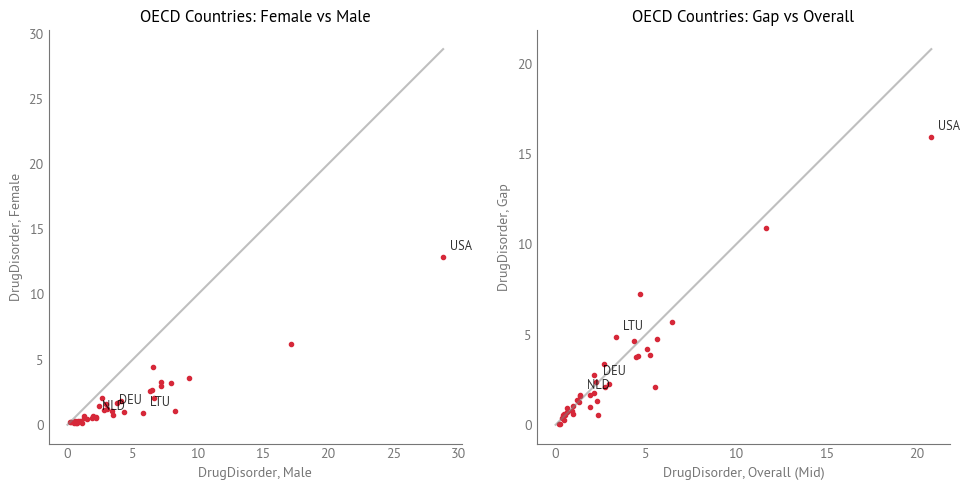

In [64]:
col = 'DrugDisorderDeathRate'
drug_disorders = drug_disorders.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
drug_disorders_gap = summarize_gap(drug_disorders, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/drug_disorders_scatter.png', dpi=300, bbox_inches='tight')

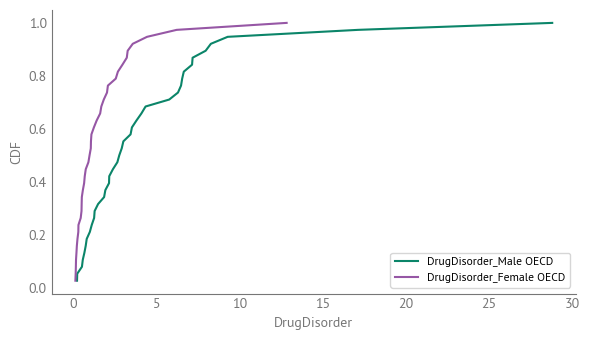

In [65]:
plot_distributions(drug_disorders_gap, indicator_name='DrugDisorder')
plt.savefig('jb/figs/drug_disorders_distributions.png', dpi=300, bbox_inches='tight')

### Diabetes Type 2 (IHME)

**Diabetes type 2 death rates (per 100,000 population)** - Deaths from diabetes mellitus type 2, from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: This is an alternative to the WHO diabetes death rate indicator (SA_0000001440) which only has data for 2004. IHME data may have better temporal coverage, allowing for more recent data to be used in the analysis. Diabetes is a chronic condition that can contribute to the gender gap in mortality, though the relationship may vary by country and healthcare access. Data includes separate male and female values, allowing for gender gap analysis.

In [66]:
filename_male = '../data/ihme_diabetes_deaths_male.csv'
filename_female = '../data/ihme_diabetes_deaths_female.csv'
diabetes_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='DiabetesDeathRate',
    indicator_code='IHME_DIABETES_TYPE2',
    indicator_name='Diabetes mellitus type 2, death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [67]:
diabetes_ihme.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,DiabetesDeathRate,DiabetesDeathRate_Low,DiabetesDeathRate_High,Country
0,IHME_DIABETES_TYPE2,"Diabetes mellitus type 2, death rate per 100,000",AUS,COUNTRY,2000.0,Female,14.248627,12.464444,15.401741,Australia
1,IHME_DIABETES_TYPE2,"Diabetes mellitus type 2, death rate per 100,000",AUS,COUNTRY,2001.0,Female,14.344688,12.349151,15.524031,Australia
2,IHME_DIABETES_TYPE2,"Diabetes mellitus type 2, death rate per 100,000",AUS,COUNTRY,2002.0,Female,14.975359,12.788477,16.260285,Australia
3,IHME_DIABETES_TYPE2,"Diabetes mellitus type 2, death rate per 100,000",AUS,COUNTRY,2003.0,Female,15.525666,13.304746,16.804496,Australia
4,IHME_DIABETES_TYPE2,"Diabetes mellitus type 2, death rate per 100,000",AUS,COUNTRY,2004.0,Female,16.080445,13.757866,17.471747,Australia


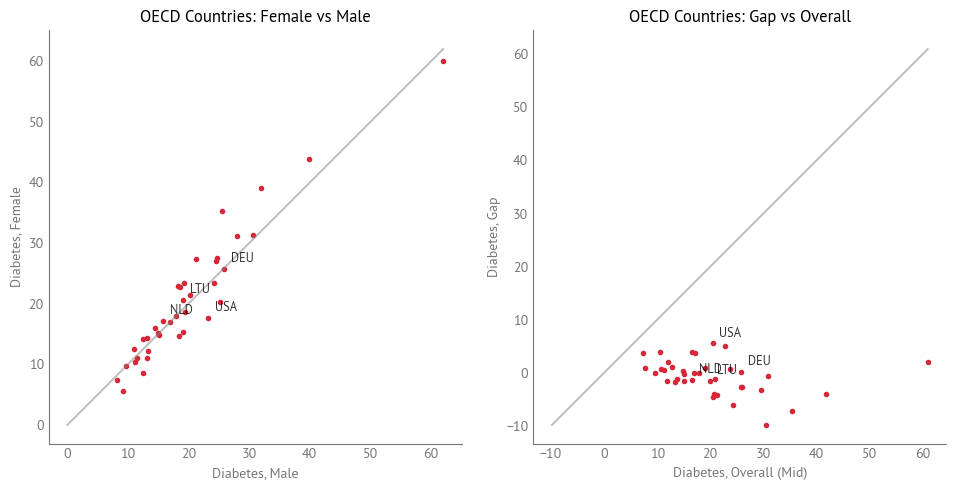

In [68]:
col = 'DiabetesDeathRate'
diabetes_ihme = diabetes_ihme.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
diabetes_ihme_gap = summarize_gap(diabetes_ihme, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/diabetes_ihme_scatter.png', dpi=300, bbox_inches='tight')

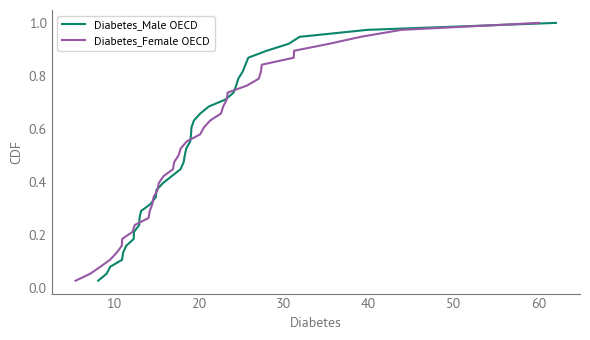

In [69]:
plot_distributions(diabetes_ihme_gap, indicator_name='Diabetes')
plt.savefig('jb/figs/diabetes_ihme_distributions.png', dpi=300, bbox_inches='tight')

### Cardiovascular Diseases (IHME)

**Cardiovascular diseases death rates (per 100,000 population)** - Deaths from cardiovascular diseases, from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Cardiovascular diseases are a major cause of death and may contribute significantly to the HALE gender gap. This is an alternative to the WHO cardiovascular disease death rate indicators which only have data for 2004. IHME data may have better temporal coverage, allowing for more recent data to be used in the analysis. Data includes separate male and female values, allowing for gender gap analysis.

In [70]:
filename_male = '../data/ihme_cardiovascular_deaths_male.csv'
filename_female = '../data/ihme_cardiovascular_deaths_female.csv'
cardiovascular_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='CardioDeathRate',
    indicator_code='IHME_CARDIOVASCULAR',
    indicator_name='Cardiovascular diseases, death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [71]:
cardiovascular_ihme.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,CardioDeathRate,CardioDeathRate_Low,CardioDeathRate_High,Country
0,IHME_CARDIOVASCULAR,"Cardiovascular diseases, death rate per 100,000",AUS,COUNTRY,2000.0,Female,259.494605,222.004192,280.150209,Australia
1,IHME_CARDIOVASCULAR,"Cardiovascular diseases, death rate per 100,000",AUS,COUNTRY,2001.0,Female,253.477767,215.393916,274.406489,Australia
2,IHME_CARDIOVASCULAR,"Cardiovascular diseases, death rate per 100,000",AUS,COUNTRY,2002.0,Female,253.122588,214.641706,274.256619,Australia
3,IHME_CARDIOVASCULAR,"Cardiovascular diseases, death rate per 100,000",AUS,COUNTRY,2003.0,Female,244.429433,205.859935,264.521285,Australia
4,IHME_CARDIOVASCULAR,"Cardiovascular diseases, death rate per 100,000",AUS,COUNTRY,2004.0,Female,235.278983,195.651019,255.862336,Australia


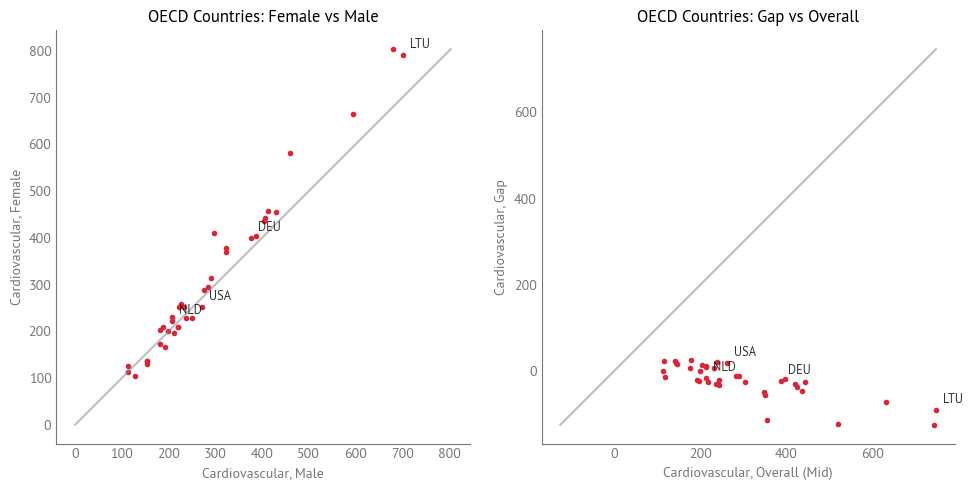

In [72]:
col = 'CardioDeathRate'
cardiovascular_ihme = cardiovascular_ihme.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
cardiovascular_ihme_gap = summarize_gap(cardiovascular_ihme, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/cardiovascular_ihme_scatter.png', dpi=300, bbox_inches='tight')

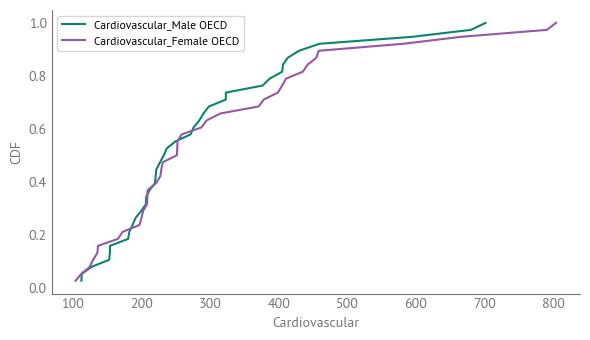

In [73]:
plot_distributions(cardiovascular_ihme_gap, indicator_name='Cardiovascular')
plt.savefig('jb/figs/cardiovascular_ihme_distributions.png', dpi=300, bbox_inches='tight')

### Neoplasms (Cancer) (IHME)

**Neoplasms (cancer) death rates (per 100,000 population)** - Deaths from neoplasms (cancer), from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Neoplasms (cancer) are a major cause of death and may contribute significantly to the HALE gender gap. Different types of cancer have different gender patterns (e.g., lung cancer is often higher in men, breast cancer is female-specific). This indicator provides comprehensive cancer death rates with better temporal coverage than WHO indicators. Data includes separate male and female values, allowing for gender gap analysis.

In [74]:
filename_male = '../data/ihme_neoplasms_deaths_male.csv'
filename_female = '../data/ihme_neoplasms_deaths_female.csv'
neoplasms_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='NeoplasmsDeathRate',
    indicator_code='IHME_NEOPLASMS',
    indicator_name='Neoplasms (cancer), death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [75]:
neoplasms_ihme.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,NeoplasmsDeathRate,NeoplasmsDeathRate_Low,NeoplasmsDeathRate_High,Country
0,IHME_NEOPLASMS,"Neoplasms (cancer), death rate per 100,000",AUS,COUNTRY,2000.0,Female,174.372594,157.339856,183.123589,Australia
1,IHME_NEOPLASMS,"Neoplasms (cancer), death rate per 100,000",AUS,COUNTRY,2001.0,Female,176.862341,159.525714,186.065679,Australia
2,IHME_NEOPLASMS,"Neoplasms (cancer), death rate per 100,000",AUS,COUNTRY,2002.0,Female,179.519671,162.651746,189.101742,Australia
3,IHME_NEOPLASMS,"Neoplasms (cancer), death rate per 100,000",AUS,COUNTRY,2003.0,Female,178.595845,160.978354,188.735833,Australia
4,IHME_NEOPLASMS,"Neoplasms (cancer), death rate per 100,000",AUS,COUNTRY,2004.0,Female,177.584662,159.143525,187.692801,Australia


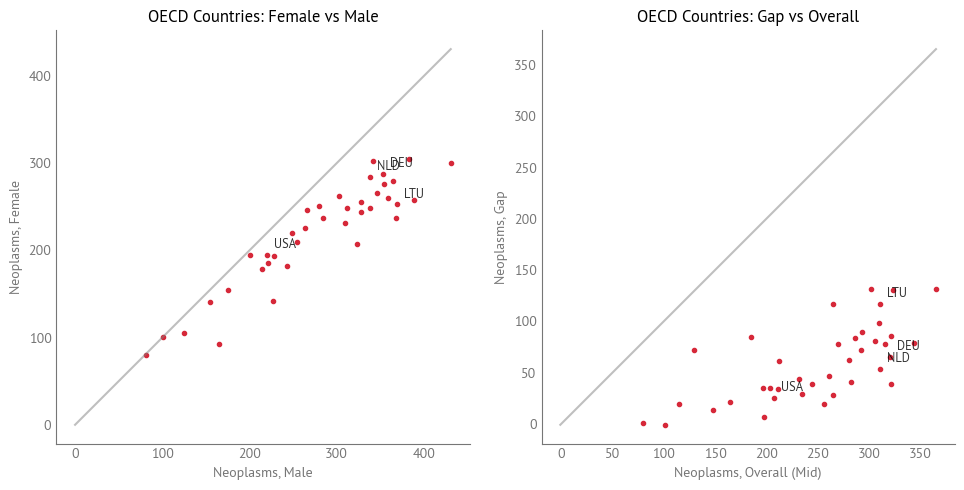

In [76]:
col = 'NeoplasmsDeathRate'
neoplasms_ihme = neoplasms_ihme.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
neoplasms_ihme_gap = summarize_gap(neoplasms_ihme, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/neoplasms_scatter.png', dpi=300, bbox_inches='tight')

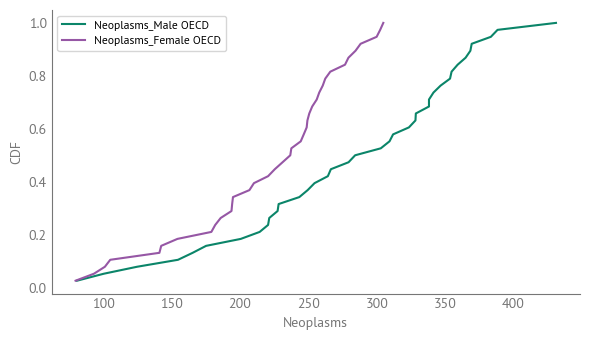

In [77]:
plot_distributions(neoplasms_ihme_gap, indicator_name='Neoplasms')
plt.savefig('jb/figs/neoplasms_distributions.png', dpi=300, bbox_inches='tight')

### Chronic Respiratory Diseases (IHME)

**Chronic respiratory diseases death rates (per 100,000 population)** - Deaths from chronic respiratory diseases (including COPD, asthma, and other chronic lung conditions), from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Chronic respiratory diseases are a major cause of death and may contribute significantly to the HALE gender gap. These diseases often have gender differences due to factors such as smoking patterns, occupational exposures, and environmental factors. This indicator provides comprehensive chronic respiratory disease death rates with better temporal coverage than WHO indicators. Data includes separate male and female values, allowing for gender gap analysis.

In [78]:
filename_male = '../data/ihme_chronic_respiratory_deaths_male.csv'
filename_female = '../data/ihme_chronic_respiratory_deaths_female.csv'
chronic_respiratory_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='ChronicRespiratoryDeathRate',
    indicator_code='IHME_CHRONIC_RESPIRATORY',
    indicator_name='Chronic respiratory diseases, death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [79]:
chronic_respiratory_ihme.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,ChronicRespiratoryDeathRate,ChronicRespiratoryDeathRate_Low,ChronicRespiratoryDeathRate_High,Country
0,IHME_CHRONIC_RESPIRATORY,"Chronic respiratory diseases, death rate per 1...",AUS,COUNTRY,2000.0,Female,33.416935,29.058943,36.594912,Australia
1,IHME_CHRONIC_RESPIRATORY,"Chronic respiratory diseases, death rate per 1...",AUS,COUNTRY,2001.0,Female,33.538075,29.034905,36.751005,Australia
2,IHME_CHRONIC_RESPIRATORY,"Chronic respiratory diseases, death rate per 1...",AUS,COUNTRY,2002.0,Female,34.771695,30.095679,38.050192,Australia
3,IHME_CHRONIC_RESPIRATORY,"Chronic respiratory diseases, death rate per 1...",AUS,COUNTRY,2003.0,Female,34.102959,29.234623,37.388706,Australia
4,IHME_CHRONIC_RESPIRATORY,"Chronic respiratory diseases, death rate per 1...",AUS,COUNTRY,2004.0,Female,33.381971,28.496299,37.070731,Australia


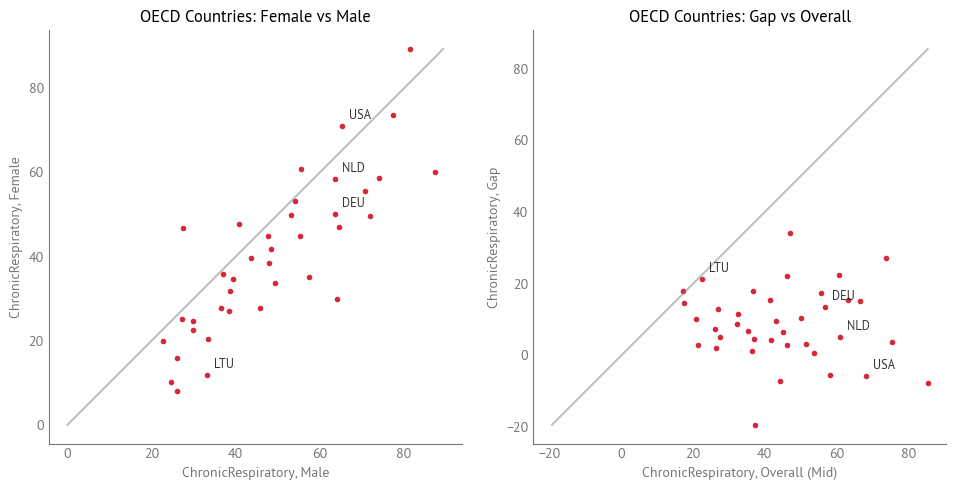

In [80]:
col = 'ChronicRespiratoryDeathRate'
chronic_respiratory_ihme = chronic_respiratory_ihme.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
chronic_respiratory_ihme_gap = summarize_gap(chronic_respiratory_ihme, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/chronic_respiratory_scatter.png', dpi=300, bbox_inches='tight')

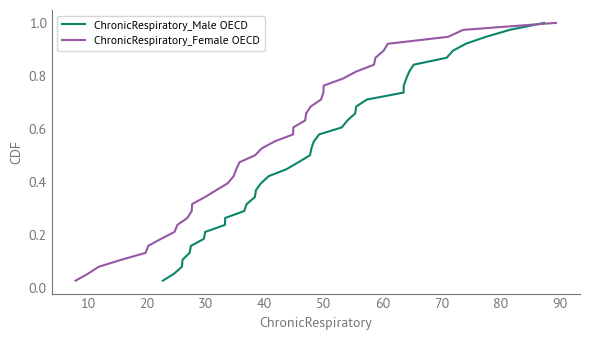

In [81]:
plot_distributions(chronic_respiratory_ihme_gap, indicator_name='ChronicRespiratory')
plt.savefig('jb/figs/chronic_respiratory_distributions.png', dpi=300, bbox_inches='tight')

### Liver Disease (Cirrhosis and Other Chronic Liver Diseases) (IHME)

**Liver disease death rates (per 100,000 population)** - Deaths from cirrhosis and other chronic liver diseases, from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Liver disease (cirrhosis and other chronic liver diseases) is a significant cause of death and may contribute to the HALE gender gap. Men typically have higher rates of liver disease mortality than women, often due to higher alcohol consumption, hepatitis infections, and other risk factors. This indicator provides comprehensive liver disease death rates with excellent temporal coverage (1990-2023, 34 years) and good country coverage. Liver disease is often related to alcohol consumption, but also includes non-alcoholic causes such as viral hepatitis, non-alcoholic fatty liver disease, and other chronic liver conditions. Data includes separate male and female values, allowing for gender gap analysis.

In [82]:
filename_male = '../data/ihme_liver_disease_deaths_male.csv'
filename_female = '../data/ihme_liver_disease_deaths_female.csv'
liver_disease_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='LiverDiseaseDeathRate',
    indicator_code='IHME_LIVER_DISEASE',
    indicator_name='Cirrhosis and other chronic liver diseases, death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [83]:
liver_disease_ihme.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,LiverDiseaseDeathRate,LiverDiseaseDeathRate_Low,LiverDiseaseDeathRate_High,Country
0,IHME_LIVER_DISEASE,"Cirrhosis and other chronic liver diseases, de...",AUS,COUNTRY,2000.0,Female,4.125954,3.588697,4.583564,Australia
1,IHME_LIVER_DISEASE,"Cirrhosis and other chronic liver diseases, de...",AUS,COUNTRY,2001.0,Female,4.028933,3.522781,4.484075,Australia
2,IHME_LIVER_DISEASE,"Cirrhosis and other chronic liver diseases, de...",AUS,COUNTRY,2002.0,Female,4.357130,3.817089,4.803285,Australia
3,IHME_LIVER_DISEASE,"Cirrhosis and other chronic liver diseases, de...",AUS,COUNTRY,2003.0,Female,4.273111,3.761031,4.717604,Australia
4,IHME_LIVER_DISEASE,"Cirrhosis and other chronic liver diseases, de...",AUS,COUNTRY,2004.0,Female,4.275616,3.791591,4.721023,Australia


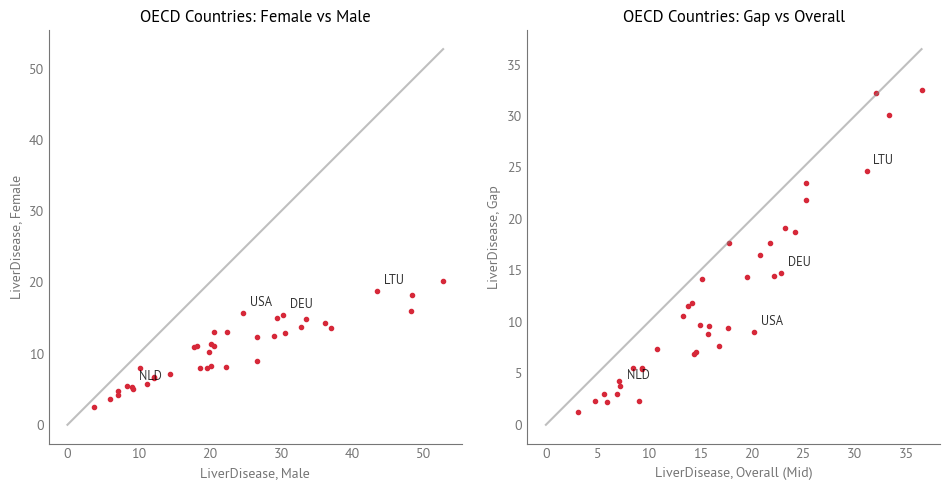

In [84]:
col = 'LiverDiseaseDeathRate'
liver_disease_ihme = liver_disease_ihme.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
liver_disease_ihme_gap = summarize_gap(liver_disease_ihme, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/liver_disease_scatter.png', dpi=300, bbox_inches='tight')

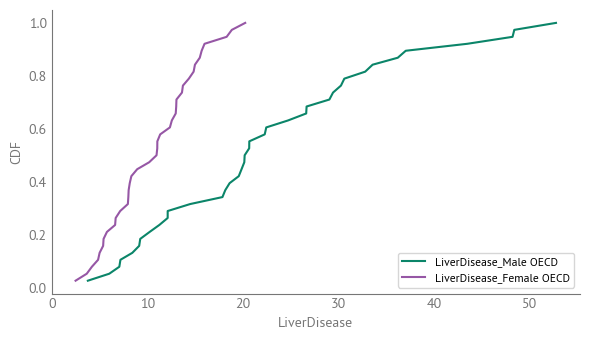

In [85]:
plot_distributions(liver_disease_ihme_gap, indicator_name='LiverDisease')
plt.savefig('jb/figs/liver_disease_distributions.png', dpi=300, bbox_inches='tight')

### Unintentional Injuries (IHME)

**Unintentional injuries death rates (per 100,000 population)** - Deaths from unintentional injuries (including falls, drowning, fires, and other accidents), from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Unintentional injuries are a significant cause of death and may contribute to the HALE gender gap. These injuries often show gender differences due to occupational exposures, risk-taking behaviors, and activity patterns. This indicator provides comprehensive unintentional injury death rates with better temporal coverage (1990-2023) than many WHO indicators. Data includes separate male and female values, allowing for gender gap analysis.

In [86]:
filename_male = '../data/ihme_unintentional_injuries_deaths_male.csv'
filename_female = '../data/ihme_unintentional_injuries_deaths_female.csv'
unintentional_injuries_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='UnintentionalInjuriesDeathRate',
    indicator_code='IHME_UNINTENTIONAL_INJURIES',
    indicator_name='Unintentional injuries, death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [87]:
unintentional_injuries_ihme.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,UnintentionalInjuriesDeathRate,UnintentionalInjuriesDeathRate_Low,UnintentionalInjuriesDeathRate_High,Country
0,IHME_UNINTENTIONAL_INJURIES,"Unintentional injuries, death rate per 100,000",AUS,COUNTRY,2000.0,Female,12.032874,10.437510,13.670943,Australia
1,IHME_UNINTENTIONAL_INJURIES,"Unintentional injuries, death rate per 100,000",AUS,COUNTRY,2001.0,Female,11.824066,10.182373,13.412276,Australia
2,IHME_UNINTENTIONAL_INJURIES,"Unintentional injuries, death rate per 100,000",AUS,COUNTRY,2002.0,Female,12.696670,10.897320,14.482235,Australia
3,IHME_UNINTENTIONAL_INJURIES,"Unintentional injuries, death rate per 100,000",AUS,COUNTRY,2003.0,Female,13.010010,11.096530,14.885208,Australia
4,IHME_UNINTENTIONAL_INJURIES,"Unintentional injuries, death rate per 100,000",AUS,COUNTRY,2004.0,Female,13.977934,11.937847,15.891603,Australia


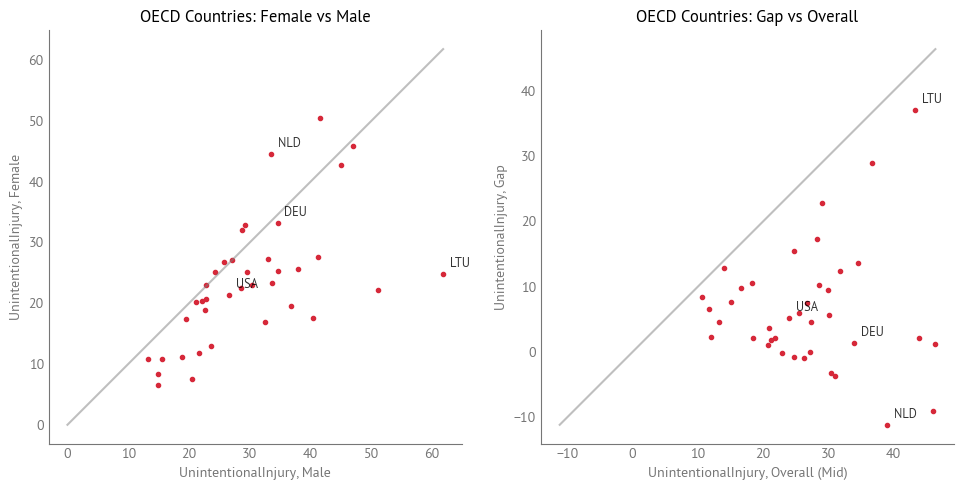

In [88]:
col = 'UnintentionalInjuriesDeathRate'
unintentional_injuries_ihme = unintentional_injuries_ihme.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
unintentional_injuries_ihme_gap = summarize_gap(unintentional_injuries_ihme, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/unintentional_injuries_scatter.png', dpi=300, bbox_inches='tight')

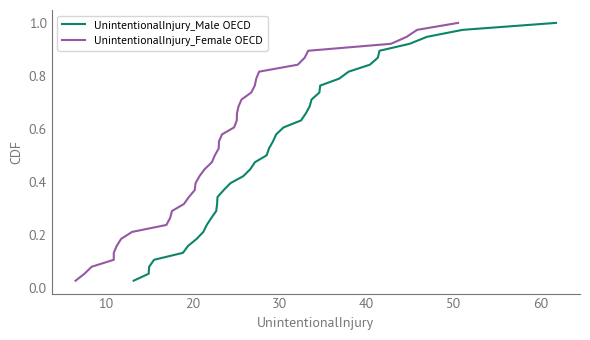

In [89]:
plot_distributions(unintentional_injuries_ihme_gap, indicator_name='UnintentionalInjury')
plt.savefig('jb/figs/unintentional_injuries_distributions.png', dpi=300, bbox_inches='tight')

### Alcohol Use Disorders (IHME) - USED IN MODEL

**Alcohol use disorders death rates (per 100,000 population)** - Deaths from alcohol use disorders, from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Alcohol use disorders are a significant cause of death and may contribute to the HALE gender gap. Men typically have higher rates of alcohol-related mortality than women. This indicator provides comprehensive alcohol use disorder death rates with excellent temporal coverage (1990-2023, 34 years) and good country coverage (40 countries). This is an alternative to the WHO alcohol-attributable death rate indicator (SA_0000001832) which only has data for 2019. **This IHME version is used in the model** because it provides much better temporal coverage, allowing for temporal analysis and more recent data. Data includes separate male and female values, allowing for gender gap analysis.

In [90]:
filename_male = '../data/ihme_alcohol_use_disorders_deaths_male.csv'
filename_female = '../data/ihme_alcohol_use_disorders_deaths_female.csv'
alcohol_use_disorders_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='AlcoholUseDisordersDeathRate',
    indicator_code='IHME_ALCOHOL_USE_DISORDERS',
    indicator_name='Alcohol use disorders, death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [91]:
alcohol_use_disorders_ihme.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,AlcoholUseDisordersDeathRate,AlcoholUseDisordersDeathRate_Low,AlcoholUseDisordersDeathRate_High,Country
0,IHME_ALCOHOL_USE_DISORDERS,"Alcohol use disorders, death rate per 100,000",AUS,COUNTRY,2000.0,Female,0.631488,0.531539,0.744281,Australia
1,IHME_ALCOHOL_USE_DISORDERS,"Alcohol use disorders, death rate per 100,000",AUS,COUNTRY,2001.0,Female,0.616363,0.515268,0.734888,Australia
2,IHME_ALCOHOL_USE_DISORDERS,"Alcohol use disorders, death rate per 100,000",AUS,COUNTRY,2002.0,Female,0.672539,0.559962,0.802278,Australia
3,IHME_ALCOHOL_USE_DISORDERS,"Alcohol use disorders, death rate per 100,000",AUS,COUNTRY,2003.0,Female,0.680933,0.564946,0.810902,Australia
4,IHME_ALCOHOL_USE_DISORDERS,"Alcohol use disorders, death rate per 100,000",AUS,COUNTRY,2004.0,Female,0.704165,0.587091,0.828949,Australia


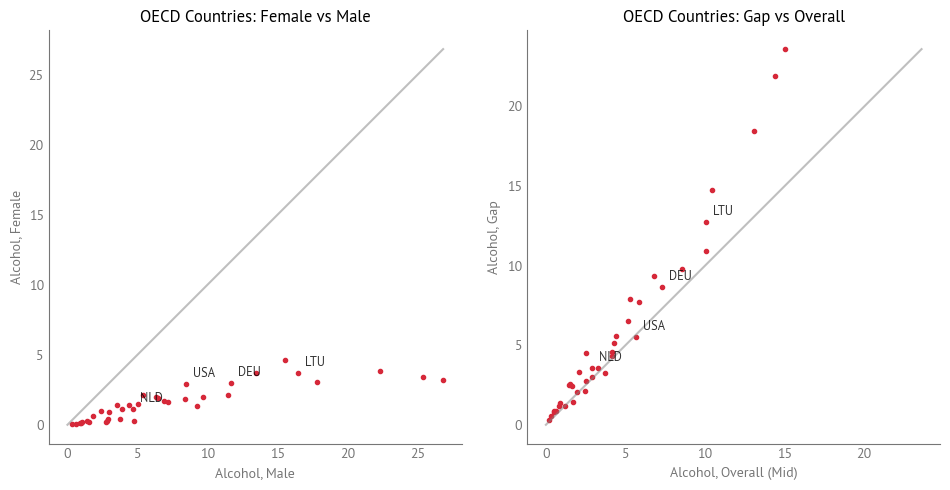

In [92]:
col = 'AlcoholUseDisordersDeathRate'
alcohol_use_disorders_ihme = alcohol_use_disorders_ihme.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
alcohol_use_disorders_ihme_gap = summarize_gap(alcohol_use_disorders_ihme, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/alcohol_ihme_scatter.png', dpi=300, bbox_inches='tight')

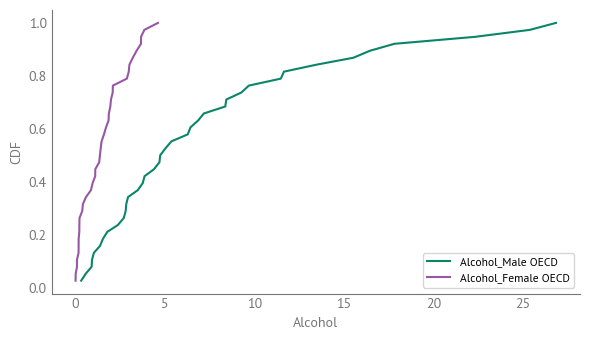

In [93]:
plot_distributions(alcohol_use_disorders_ihme_gap, indicator_name='Alcohol')
plt.savefig('jb/figs/alcohol_ihme_distributions.png', dpi=300, bbox_inches='tight')

### Self-Harm (IHME) - USED IN MODEL

**Self-harm (suicide) death rates (per 100,000 population)** - Deaths from self-harm (suicide), from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Self-harm (suicide) is a significant cause of death and contributes to the HALE gender gap. Men typically have much higher suicide rates than women in most countries. This indicator provides comprehensive self-harm death rates with excellent temporal coverage (1990-2023, 34 years) and good country coverage (40 countries). This is an alternative to the WHO suicide rate indicator (MH_12) which has data for 2000-2021. **This IHME version is used in the model** because it provides better temporal coverage (starting from 1990) and consistent methodology with other IHME indicators. Data includes separate male and female values, allowing for gender gap analysis.

In [94]:
filename_male = '../data/ihme_self_harm_deaths_male.csv'
filename_female = '../data/ihme_self_harm_deaths_female.csv'
self_harm_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='SelfHarmDeathRate',
    indicator_code='IHME_SELF_HARM',
    indicator_name='Self-harm (suicide), death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [95]:
self_harm_ihme.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,SelfHarmDeathRate,SelfHarmDeathRate_Low,SelfHarmDeathRate_High,Country
0,IHME_SELF_HARM,"Self-harm (suicide), death rate per 100,000",AUS,COUNTRY,2000.0,Female,5.627537,5.216050,6.147375,Australia
1,IHME_SELF_HARM,"Self-harm (suicide), death rate per 100,000",AUS,COUNTRY,2001.0,Female,5.677859,5.274716,6.153598,Australia
2,IHME_SELF_HARM,"Self-harm (suicide), death rate per 100,000",AUS,COUNTRY,2002.0,Female,5.484698,5.066802,5.936228,Australia
3,IHME_SELF_HARM,"Self-harm (suicide), death rate per 100,000",AUS,COUNTRY,2003.0,Female,5.150209,4.754025,5.573173,Australia
4,IHME_SELF_HARM,"Self-harm (suicide), death rate per 100,000",AUS,COUNTRY,2004.0,Female,4.923421,4.518087,5.374432,Australia


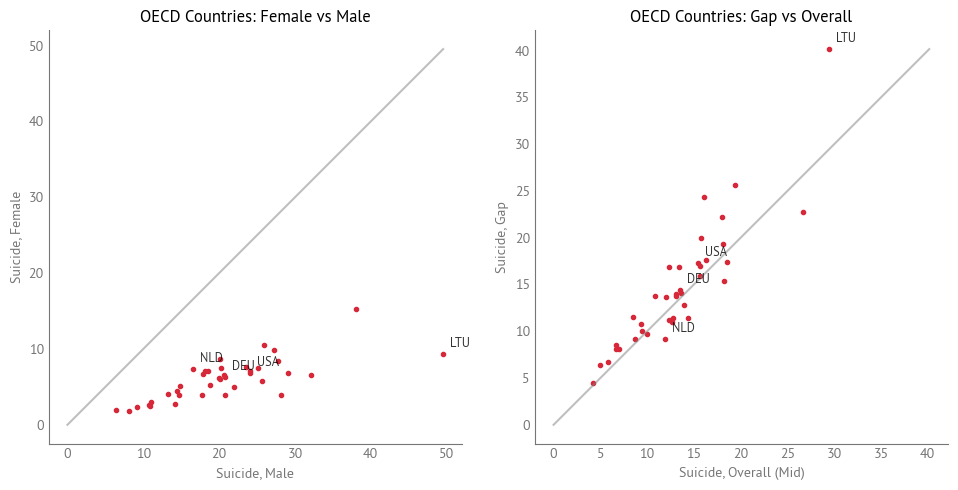

In [96]:
col = 'SelfHarmDeathRate'
self_harm_ihme = self_harm_ihme.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
self_harm_ihme_gap = summarize_gap(self_harm_ihme, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/self_harm_scatter.png', dpi=300, bbox_inches='tight')

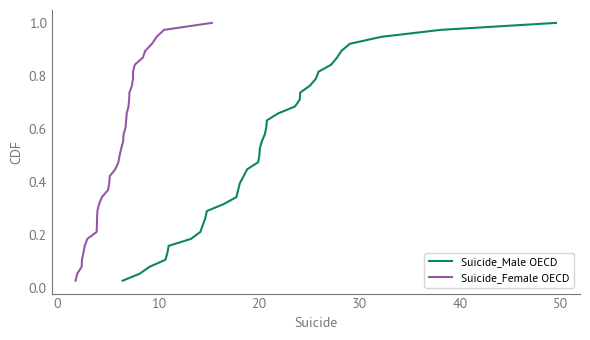

In [97]:
plot_distributions(self_harm_ihme_gap, indicator_name='Suicide')
plt.savefig('jb/figs/self_harm_distributions.png', dpi=300, bbox_inches='tight')

### Interpersonal Violence (IHME) - USED IN MODEL

**Interpersonal violence (homicide) death rates (per 100,000 population)** - Deaths from interpersonal violence (homicide), from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Interpersonal violence (homicide) is a significant cause of death and contributes to the HALE gender gap. Men typically have much higher homicide rates than women in most countries. This indicator provides comprehensive interpersonal violence death rates with excellent temporal coverage (1990-2023, 34 years) and good country coverage (40 countries). This is an alternative to the WHO homicide rate indicator (VIOLENCE_HOMICIDERATE) which has data for 2000-2021. **This IHME version is used in the model** because it provides better temporal coverage (starting from 1990) and consistent methodology with other IHME indicators. Data includes separate male and female values, allowing for gender gap analysis.

In [98]:
filename_male = '../data/ihme_interpersonal_violence_deaths_male.csv'
filename_female = '../data/ihme_interpersonal_violence_deaths_female.csv'
interpersonal_violence_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='InterpersonalViolenceDeathRate',
    indicator_code='IHME_INTERPERSONAL_VIOLENCE',
    indicator_name='Interpersonal violence (homicide), death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [99]:
interpersonal_violence_ihme.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,InterpersonalViolenceDeathRate,InterpersonalViolenceDeathRate_Low,InterpersonalViolenceDeathRate_High,Country
0,IHME_INTERPERSONAL_VIOLENCE,"Interpersonal violence (homicide), death rate ...",AUS,COUNTRY,2000.0,Female,1.220574,1.090956,1.357464,Australia
1,IHME_INTERPERSONAL_VIOLENCE,"Interpersonal violence (homicide), death rate ...",AUS,COUNTRY,2001.0,Female,1.155846,1.038801,1.287543,Australia
2,IHME_INTERPERSONAL_VIOLENCE,"Interpersonal violence (homicide), death rate ...",AUS,COUNTRY,2002.0,Female,1.080767,0.973158,1.215679,Australia
3,IHME_INTERPERSONAL_VIOLENCE,"Interpersonal violence (homicide), death rate ...",AUS,COUNTRY,2003.0,Female,0.889872,0.802525,1.001721,Australia
4,IHME_INTERPERSONAL_VIOLENCE,"Interpersonal violence (homicide), death rate ...",AUS,COUNTRY,2004.0,Female,0.758536,0.681027,0.855067,Australia


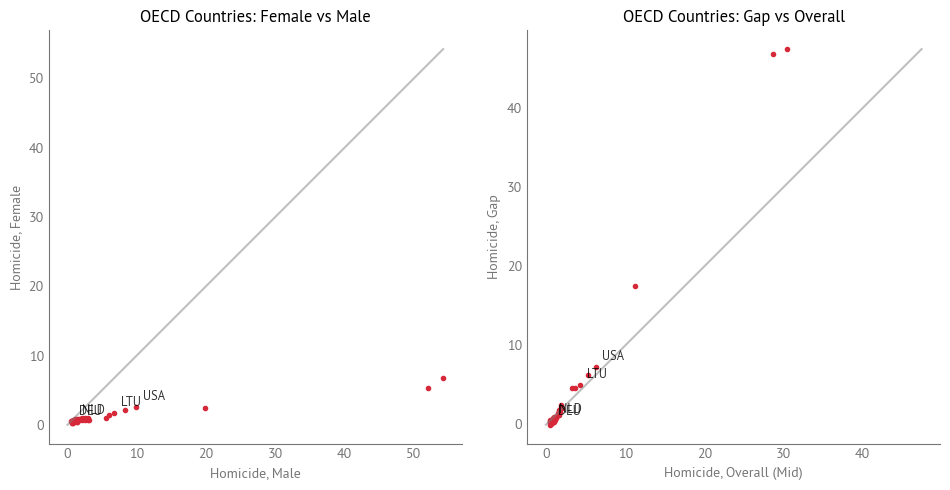

In [100]:
col = 'InterpersonalViolenceDeathRate'
interpersonal_violence_ihme = interpersonal_violence_ihme.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
interpersonal_violence_ihme_gap = summarize_gap(interpersonal_violence_ihme, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/interpersonal_violence_scatter.png', dpi=300, bbox_inches='tight')

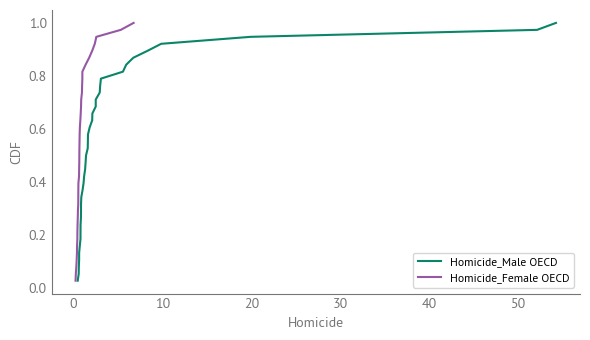

In [101]:
plot_distributions(interpersonal_violence_ihme_gap, indicator_name='Homicide')
plt.savefig('jb/figs/interpersonal_violence_distributions.png', dpi=300, bbox_inches='tight')

### Road Injuries (IHME) - USED IN MODEL

**Road injuries (road traffic crash) death rates (per 100,000 population)** - Deaths from road injuries (road traffic crashes), from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Road injuries (road traffic crashes) are a significant cause of death and contribute to the HALE gender gap. Men typically have 2-4 times higher road traffic death rates than women in most countries due to higher exposure to driving (including occupational exposure), occupational hazards, and potentially risk-taking behaviors. This indicator provides comprehensive road injury death rates with excellent temporal coverage (1990-2023, 34 years) and good country coverage (40 countries). This is an alternative to the WHO road traffic crash death rate indicator (SA_0000001459) which only has data for 2019. **This IHME version is used in the model** because it provides much better temporal coverage (1990-2023 vs 2019 only) and consistent methodology with other IHME indicators. Data includes separate male and female values, allowing for gender gap analysis.

In [102]:
filename_male = '../data/ihme_road_injuries_deaths_male.csv'
filename_female = '../data/ihme_road_injuries_deaths_female.csv'
road_injuries_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='RoadInjuriesDeathRate',
    indicator_code='IHME_ROAD_INJURIES',
    indicator_name='Road injuries (road traffic crashes), death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [103]:
road_injuries_ihme.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,RoadInjuriesDeathRate,RoadInjuriesDeathRate_Low,RoadInjuriesDeathRate_High,Country
0,IHME_ROAD_INJURIES,"Road injuries (road traffic crashes), death ra...",AUS,COUNTRY,2000.0,Female,6.084094,5.568374,6.582913,Australia
1,IHME_ROAD_INJURIES,"Road injuries (road traffic crashes), death ra...",AUS,COUNTRY,2001.0,Female,5.782579,5.258684,6.235018,Australia
2,IHME_ROAD_INJURIES,"Road injuries (road traffic crashes), death ra...",AUS,COUNTRY,2002.0,Female,5.545272,5.058701,5.981018,Australia
3,IHME_ROAD_INJURIES,"Road injuries (road traffic crashes), death ra...",AUS,COUNTRY,2003.0,Female,5.210589,4.736477,5.600680,Australia
4,IHME_ROAD_INJURIES,"Road injuries (road traffic crashes), death ra...",AUS,COUNTRY,2004.0,Female,4.897544,4.475352,5.284221,Australia


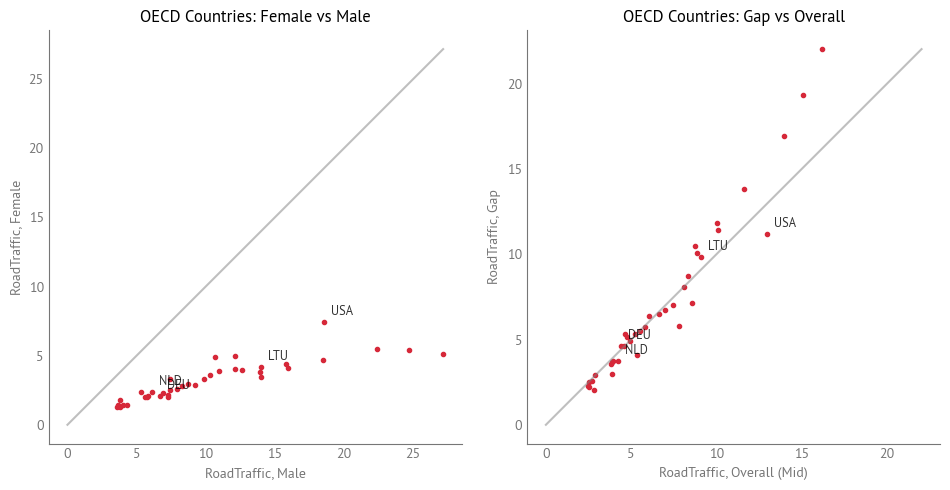

In [104]:
col = 'RoadInjuriesDeathRate'
road_injuries_ihme = road_injuries_ihme.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
road_injuries_ihme_gap = summarize_gap(road_injuries_ihme, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/road_injuries_scatter.png', dpi=300, bbox_inches='tight')

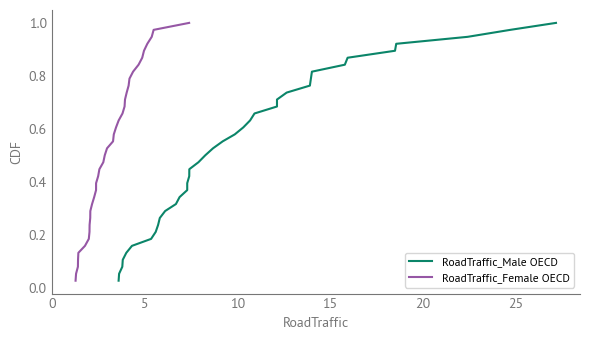

In [105]:
plot_distributions(road_injuries_ihme_gap, indicator_name='RoadTraffic')
plt.savefig('jb/figs/road_injuries_distributions.png', dpi=300, bbox_inches='tight')

### Maternal Disorders (IHME)

**Maternal disorders death rates (per 100,000 population)** - Deaths from maternal disorders, from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Maternal disorders (maternal mortality) are a significant cause of death for women and can contribute to the HALE gender gap, especially in lower-income countries. High maternal mortality can significantly reduce female life expectancy, explaining why some countries have smaller gender gaps. This indicator provides comprehensive maternal disorder death rates with excellent temporal coverage (1990-2023, 34 years) and good country coverage (40 countries). This is an alternative to the WHO maternal mortality ratio indicator (MDG_0000000026) which has data for 1985-2023. Note: WHO indicator uses ratio per 100,000 live births, while IHME uses rate per 100,000 population, so they measure slightly different things. IHME data may be useful for temporal analysis and provides consistent methodology with other IHME indicators. Inherently female-specific, so only female values are used in analysis.

In [106]:
filename_female = '../data/ihme_maternal_disorders_deaths_female.csv'
# Maternal disorders is female-only, so we need to handle it differently
# Load the female file and create a compatible format
maternal_disorders_ihme_female = pd.read_csv(filename_female)

# Filter to 2000-2019 (exclude 2020+ for COVID-19 reasons)
maternal_disorders_ihme_female = maternal_disorders_ihme_female.query('Year >= 2000 and Year <= 2019')

# Filter to "All ages" (if Age column exists)
if 'Age' in maternal_disorders_ihme_female.columns:
    maternal_disorders_ihme_female = maternal_disorders_ihme_female.query('Age == "All ages"')

# Map IHME country names to WHO country names
who_country_to_code = {country: code for code, country in code_to_who_country.items()}
ihme_country_name_mapping = {
    'Republic of Korea': 'South Korea',
    'United States of America': 'United States'
}
maternal_disorders_ihme_female['Location'] = maternal_disorders_ihme_female['Location'].replace(ihme_country_name_mapping)

# Convert country names to codes
maternal_disorders_ihme_female['Code'] = maternal_disorders_ihme_female['Location'].map(who_country_to_code)

# Filter out rows where country mapping failed
maternal_disorders_ihme_female = maternal_disorders_ihme_female[maternal_disorders_ihme_female['Code'].notna()].copy()

# Set Sex column to Female
maternal_disorders_ihme_female['Sex'] = 'Female'

# Rename and create columns to match WHO format
maternal_disorders_ihme_female['IndicatorCode'] = 'IHME_MATERNAL_DISORDERS'
maternal_disorders_ihme_female['IndicatorName'] = 'Maternal disorders, death rate per 100,000'
maternal_disorders_ihme_female['CountryCode'] = 'COUNTRY'
maternal_disorders_ihme_female['MaternalDisordersDeathRate'] = maternal_disorders_ihme_female['Value']
maternal_disorders_ihme_female['MaternalDisordersDeathRate_Low'] = maternal_disorders_ihme_female['Lower bound']
maternal_disorders_ihme_female['MaternalDisordersDeathRate_High'] = maternal_disorders_ihme_female['Upper bound']
maternal_disorders_ihme_female['Country'] = maternal_disorders_ihme_female['Location']

# Select and reorder columns to match WHO format
columns_to_keep = [
    'IndicatorCode', 'IndicatorName', 'Code', 'CountryCode', 'Year', 'Sex',
    'MaternalDisordersDeathRate', 'MaternalDisordersDeathRate_Low', 'MaternalDisordersDeathRate_High',
    'Country'
]
maternal_disorders_ihme = maternal_disorders_ihme_female[columns_to_keep].copy()

# Sort by country and year
maternal_disorders_ihme = maternal_disorders_ihme.sort_values(['Country', 'Year']).reset_index(drop=True)

years = maternal_disorders_ihme['Year'].unique()

print(maternal_disorders_ihme.shape)
print(f"Years: {years.min():.0f} - {years.max():.0f}")
print(f"Countries: {maternal_disorders_ihme['Country'].nunique()}")
print(f"Sex categories: {maternal_disorders_ihme['Sex'].unique()}")

(760, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female']


In [107]:
maternal_disorders_ihme.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,MaternalDisordersDeathRate,MaternalDisordersDeathRate_Low,MaternalDisordersDeathRate_High,Country
0,IHME_MATERNAL_DISORDERS,"Maternal disorders, death rate per 100,000",AUS,COUNTRY,2000.0,Female,0.190818,0.164745,0.219467,Australia
1,IHME_MATERNAL_DISORDERS,"Maternal disorders, death rate per 100,000",AUS,COUNTRY,2001.0,Female,0.167333,0.144367,0.192226,Australia
2,IHME_MATERNAL_DISORDERS,"Maternal disorders, death rate per 100,000",AUS,COUNTRY,2002.0,Female,0.189218,0.161726,0.215605,Australia
3,IHME_MATERNAL_DISORDERS,"Maternal disorders, death rate per 100,000",AUS,COUNTRY,2003.0,Female,0.124994,0.107358,0.143600,Australia
4,IHME_MATERNAL_DISORDERS,"Maternal disorders, death rate per 100,000",AUS,COUNTRY,2004.0,Female,0.147857,0.126645,0.171856,Australia


In [108]:
col = 'MaternalDisordersDeathRate'
maternal_disorders_ihme = maternal_disorders_ihme.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
maternal_disorders_ihme_gap = summarize_gap(maternal_disorders_ihme, col, sexes=['Female'], cutoff_year=cutoff_year)
plt.savefig('jb/figs/maternal_disorders_scatter.png', dpi=300, bbox_inches='tight')

<Figure size 600x350 with 0 Axes>

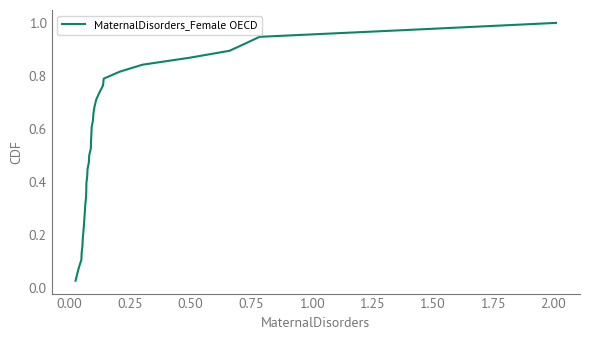

In [109]:
plot_distributions(maternal_disorders_ihme_gap, indicator_name='MaternalDisorders')
plt.savefig('jb/figs/maternal_disorders_distributions.png', dpi=300, bbox_inches='tight')

### All-Cause Deaths Under 5 Years of Age (IHME) - USED IN MODEL

**All-cause deaths under 5 years of age (per 100,000 population)** - Deaths from all causes for children under 5 years of age, from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: All-cause mortality for children under 5 years of age is relevant to the HALE gender gap because HALE is calculated from birth, so early-life mortality directly affects HALE calculations. If child mortality differs by gender, it directly contributes to the HALE gender gap. Infant and child mortality is typically higher in males (biological vulnerability + some behavioral factors). **This IHME version is used in the model** because it provides better temporal coverage (1990-2023) and consistent methodology with other IHME indicators. This is different from the WHO under-five mortality rate (U5MR, MDG_0000000007) which measures deaths per 1,000 live births. The IHME indicator measures deaths per 100,000 population, providing a complementary perspective on early-life mortality. Data includes separate male and female values, allowing for gender gap analysis.

In [110]:
filename_male = '../data/ihme_all_causes_under5_deaths_male.csv'
filename_female = '../data/ihme_all_causes_under5_deaths_female.csv'
# All-cause under 5 needs special handling because it's for "<5 years" age group, not "All ages"
# We'll create a modified version of load_ihme_indicator that filters for "<5 years" instead

def load_ihme_indicator_under5(filename_male, filename_female, value_col_name, indicator_code, indicator_name):
    """
    Load IHME indicator data for under-5 age group from separate male and female files.
    
    Similar to load_ihme_indicator but filters for "<5 years" age group instead of "All ages".
    """
    # Create reverse mapping from country name to code
    who_country_to_code = {country: code for code, country in code_to_who_country.items()}
    
    # Map IHME country names that differ from WHO names
    ihme_country_name_mapping = {
        'Republic of Korea': 'South Korea',
        'United States of America': 'United States'
    }
    
    def process_ihme_file(filename, sex_value):
        """Helper function to process a single IHME file."""
        df = pd.read_csv(filename)
        
        # Filter to 2000-2019 (exclude 2020+ for COVID-19 reasons)
        df = df.query('Year >= 2000 and Year <= 2019')
        
        # Filter to "<5 years" age group
        if 'Age' in df.columns:
            df = df.query('Age == "<5 years"')
        
        # Map IHME country names to WHO country names
        df['Location'] = df['Location'].replace(ihme_country_name_mapping)
        
        # Convert country names to codes
        df['Code'] = df['Location'].map(who_country_to_code)
        
        # Filter out rows where country mapping failed (not in our country list)
        df = df[df['Code'].notna()].copy()
        
        # Set Sex column to the specified value (Male or Female)
        df['Sex'] = sex_value
        
        # Rename and create columns to match WHO format
        df['IndicatorCode'] = indicator_code
        df['IndicatorName'] = indicator_name
        df['CountryCode'] = 'COUNTRY'
        df[value_col_name] = df['Value']
        df[f'{value_col_name}_Low'] = df['Lower bound']
        df[f'{value_col_name}_High'] = df['Upper bound']
        df['Country'] = df['Location']
        
        # Select and reorder columns to match WHO format
        columns_to_keep = [
            'IndicatorCode', 'IndicatorName', 'Code', 'CountryCode', 'Year', 'Sex',
            value_col_name, f'{value_col_name}_Low', f'{value_col_name}_High',
            'Country'
        ]
        df = df[columns_to_keep].copy()
        
        return df
    
    # Load and process both files
    df_male = process_ihme_file(filename_male, 'Male')
    df_female = process_ihme_file(filename_female, 'Female')
    
    # Concatenate male and female data
    df = pd.concat([df_male, df_female], ignore_index=True)
    
    # Sort by country, sex, and year
    df = df.sort_values(['Country', 'Sex', 'Year']).reset_index(drop=True)
    
    years = df['Year'].unique()
    
    print(df.shape)
    print(f"Years: {years.min():.0f} - {years.max():.0f}")
    print(f"Countries: {df['Country'].nunique()}")
    print(f"Sex categories: {df['Sex'].unique()}")
    
    return df, years

all_causes_under5_ihme, years = load_ihme_indicator_under5(
    filename_male, filename_female,
    value_col_name='AllCausesUnder5DeathRate',
    indicator_code='IHME_ALL_CAUSES_UNDER5',
    indicator_name='All-cause deaths under 5 years, death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [111]:
all_causes_under5_ihme.head()

,IndicatorCode,IndicatorName,Code,CountryCode,Year,Sex,AllCausesUnder5DeathRate,AllCausesUnder5DeathRate_Low,AllCausesUnder5DeathRate_High,Country
0,IHME_ALL_CAUSES_UNDER5,"All-cause deaths under 5 years, death rate per...",AUS,COUNTRY,2000.0,Female,108.987394,105.694199,112.339690,Australia
1,IHME_ALL_CAUSES_UNDER5,"All-cause deaths under 5 years, death rate per...",AUS,COUNTRY,2001.0,Female,107.017794,103.828800,110.342158,Australia
2,IHME_ALL_CAUSES_UNDER5,"All-cause deaths under 5 years, death rate per...",AUS,COUNTRY,2002.0,Female,105.199071,102.004207,108.668812,Australia
3,IHME_ALL_CAUSES_UNDER5,"All-cause deaths under 5 years, death rate per...",AUS,COUNTRY,2003.0,Female,103.204037,99.864006,106.604800,Australia
4,IHME_ALL_CAUSES_UNDER5,"All-cause deaths under 5 years, death rate per...",AUS,COUNTRY,2004.0,Female,102.167493,98.843241,105.603340,Australia


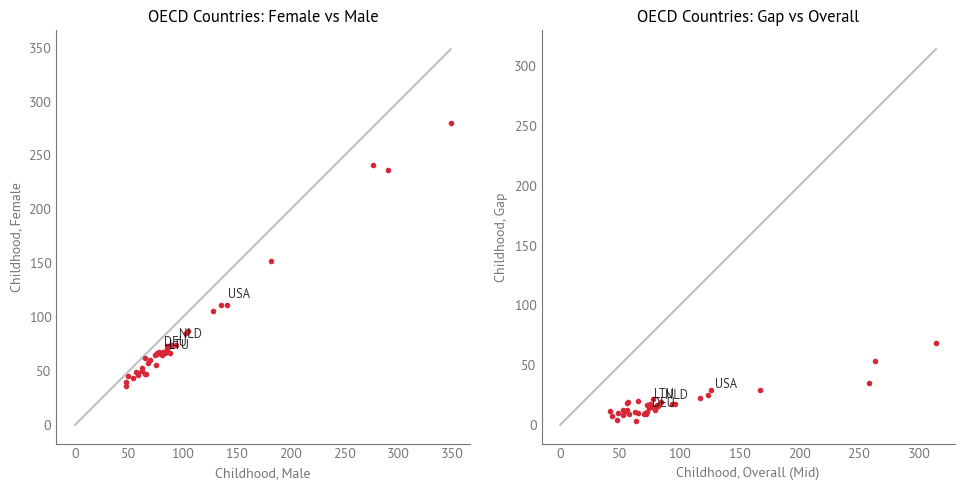

In [112]:
col = 'AllCausesUnder5DeathRate'
all_causes_under5_ihme = all_causes_under5_ihme.rename(columns=column_name_mapping)
col = column_name_mapping.get(col, col)
all_causes_under5_ihme_gap = summarize_gap(all_causes_under5_ihme, col, cutoff_year=cutoff_year)
plt.savefig('jb/figs/all_causes_under5_scatter.png', dpi=300, bbox_inches='tight')

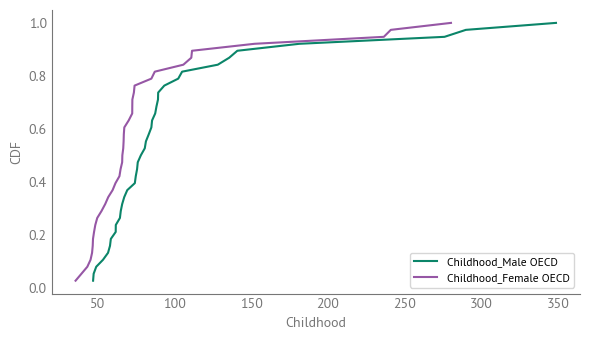

In [113]:
plot_distributions(all_causes_under5_ihme_gap, indicator_name='Childhood')
plt.savefig('jb/figs/all_causes_under5_distributions.png', dpi=300, bbox_inches='tight')

## Comparing WHO and IHME Indicators

This section compares indicators where we have data from both WHO and IHME sources. For each indicator, we show side-by-side scatter plots comparing the gender gap values, using the same axis scaling to facilitate comparison.

In [114]:
# Function to create side-by-side comparison plots
def compare_who_ihme(who_df, ihme_df, who_col, ihme_col, who_label, ihme_label, title):
    """
    Create side-by-side scatter plots comparing WHO and IHME gap values.
    
    Parameters
    ----------
    who_df : pandas.DataFrame
        DataFrame with WHO data, indexed by country code
    ihme_df : pandas.DataFrame
        DataFrame with IHME data, indexed by country code
    who_col : str
        Column name for WHO gap values (e.g., 'Gap_Alcohol')
    ihme_col : str
        Column name for IHME gap values (e.g., 'Gap_Alcohol')
    who_label : str
        Label for WHO indicator
    ihme_label : str
        Label for IHME indicator
    title : str
        Overall title for the comparison
    """
    # Get OECD countries for both datasets
    who_oecd = get_oecd(who_df)
    ihme_oecd = get_oecd(ihme_df)
    
    # Find common countries
    common_countries = who_oecd.index.intersection(ihme_oecd.index)
    who_common = who_oecd.loc[common_countries]
    ihme_common = ihme_oecd.loc[common_countries]
    
    # Get all values to determine domain
    all_values = []
    if who_col in who_common.columns:
        all_values.extend(who_common[who_col].dropna().tolist())
    if ihme_col in ihme_common.columns:
        all_values.extend(ihme_common[ihme_col].dropna().tolist())
    
    if not all_values:
        print(f"No data available for {title}")
        return
    
    domain = [0, max(all_values) * 1.05]  # Add 5% padding
    
    # Create side-by-side distribution plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot WHO distribution
    plt.sca(ax1)
    if who_col in who_common.columns:
        who_values = who_common[who_col].dropna()
        # Get Male and Female columns for scatter plot
        who_male_col = who_col.replace('Gap_', '') + '_Male'
        who_female_col = who_col.replace('Gap_', '') + '_Female'
        
        if who_male_col in who_common.columns and who_female_col in who_common.columns:
            scatter_plot(who_common, [who_male_col, who_female_col], domain,
                        xlabel=f'{who_label} Male',
                        ylabel=f'{who_label} Female',
                        title=f'WHO: {who_label}')
        else:
            ax1.text(0.5, 0.5, f'Missing Male/Female columns', 
                    ha='center', va='center', transform=ax1.transAxes)
            ax1.set_title(f'WHO: {who_label}')
    else:
        ax1.text(0.5, 0.5, f'No {who_col} column', 
                ha='center', va='center', transform=ax1.transAxes)
        ax1.set_title(f'WHO: {who_label}')
    
    # Plot IHME distribution
    plt.sca(ax2)
    if ihme_col in ihme_common.columns:
        ihme_values = ihme_common[ihme_col].dropna()
        # Get Male and Female columns for scatter plot
        ihme_male_col = ihme_col.replace('Gap_', '') + '_Male'
        ihme_female_col = ihme_col.replace('Gap_', '') + '_Female'
        
        if ihme_male_col in ihme_common.columns and ihme_female_col in ihme_common.columns:
            scatter_plot(ihme_common, [ihme_male_col, ihme_female_col], domain,
                        xlabel=f'{ihme_label} Male',
                        ylabel=f'{ihme_label} Female',
                        title=f'IHME: {ihme_label}')
        else:
            ax2.text(0.5, 0.5, f'Missing Male/Female columns', 
                    ha='center', va='center', transform=ax2.transAxes)
            ax2.set_title(f'IHME: {ihme_label}')
    else:
        ax2.text(0.5, 0.5, f'No {ihme_col} column', 
                ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title(f'IHME: {ihme_label}')
    
    plt.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    # Save side-by-side comparison figure
    # Create clean filename from title
    clean_title = title.lower().replace(" ", "_").replace(":", "").replace("(", "").replace(")", "").replace("-", "_")
    fig_filename = f'jb/figs/who_ihme_comparison_{clean_title}.png'
    plt.savefig(fig_filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    # Create direct comparison scatter plot (WHO vs IHME)
    if who_col in who_common.columns and ihme_col in ihme_common.columns:
        # Merge on index (country codes)
        comparison_df = pd.DataFrame({
            who_label: who_common[who_col],
            ihme_label: ihme_common[ihme_col]
        })
        comparison_df = comparison_df.dropna()
        
        if len(comparison_df) > 0:
            # Determine domain for comparison plot (use same domain for both axes)
            comp_domain = [0, max(comparison_df.max()) * 1.05]
            
            plt.figure(figsize=(8, 8))
            scatter_plot(comparison_df, [who_label, ihme_label], comp_domain,
                        xlabel=f'WHO {who_label} Gap',
                        ylabel=f'IHME {ihme_label} Gap',
                        title=f'{title}: Gap Comparison')
            # Save direct comparison scatter plot
            scatter_filename = f'jb/figs/who_ihme_scatter_{clean_title}.png'
            plt.savefig(scatter_filename, dpi=300, bbox_inches='tight')
            plt.show()
        else:
            print(f"No overlapping data for {title}")
    else:
        print(f"Missing columns: WHO={who_col in who_common.columns}, IHME={ihme_col in ihme_common.columns}")

### Alcohol: WHO vs IHME

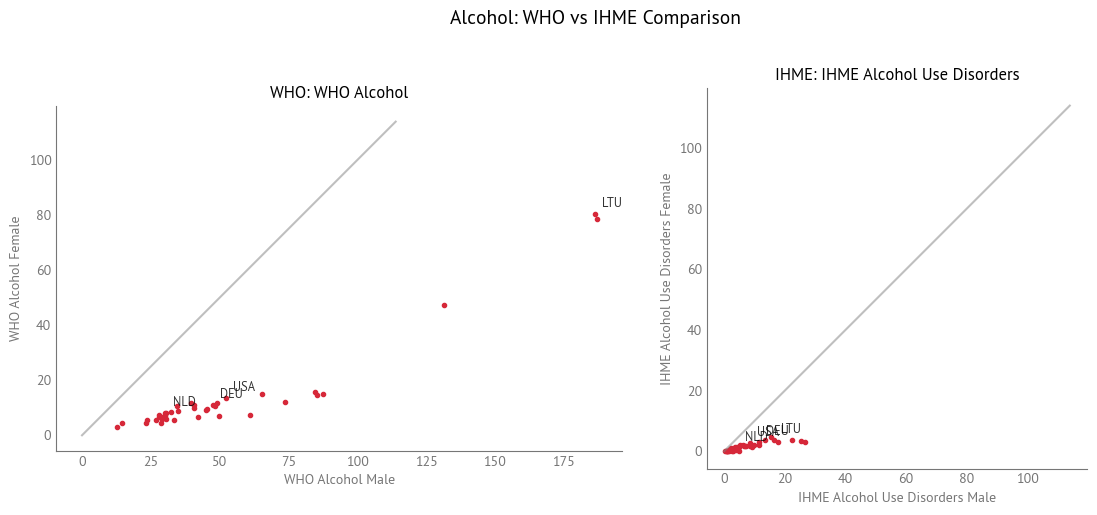

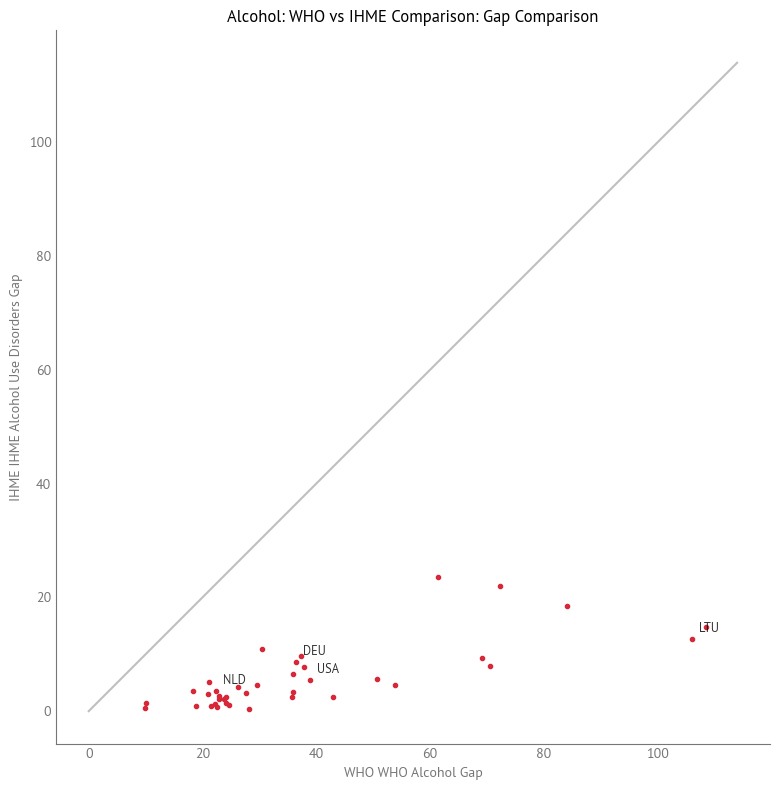

In [115]:
compare_who_ihme(
    alcohol_gap, alcohol_use_disorders_ihme_gap,
    'Gap_Alcohol', 'Gap_Alcohol',
    'WHO Alcohol', 'IHME Alcohol Use Disorders',
    'Alcohol: WHO vs IHME Comparison'
)

### Suicide: WHO vs IHME

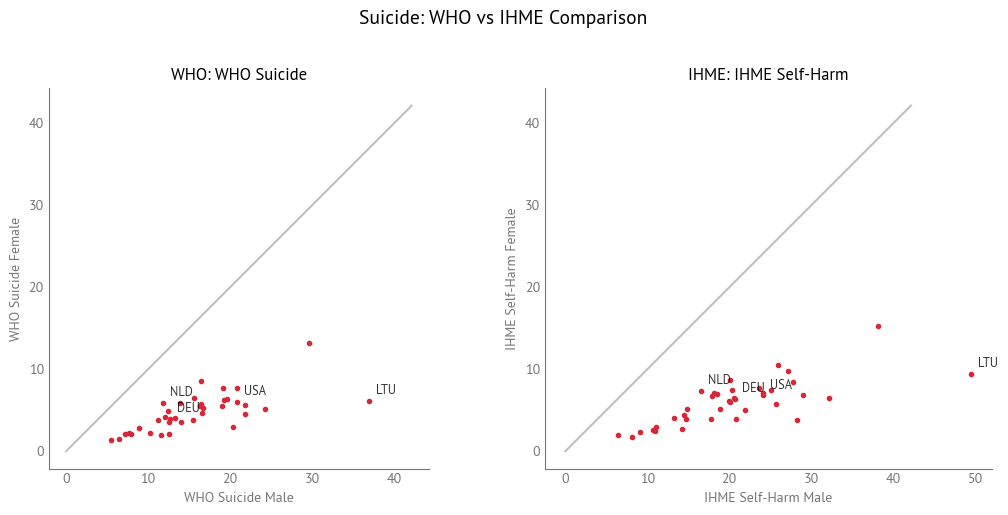

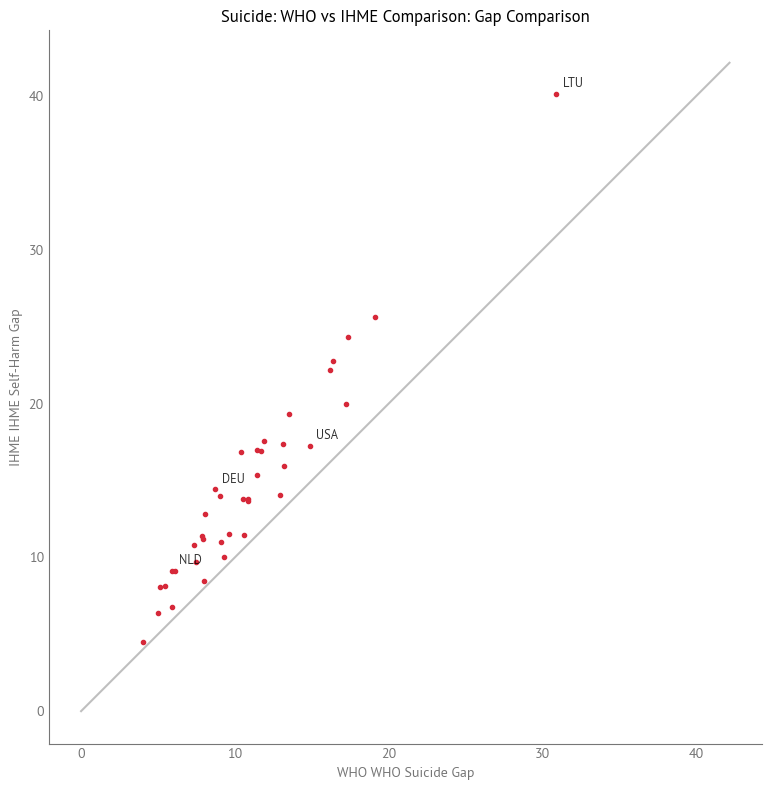

In [116]:
compare_who_ihme(
    suicide_gap, self_harm_ihme_gap,
    'Gap_Suicide', 'Gap_Suicide',
    'WHO Suicide', 'IHME Self-Harm',
    'Suicide: WHO vs IHME Comparison'
)

### Homicide: WHO vs IHME

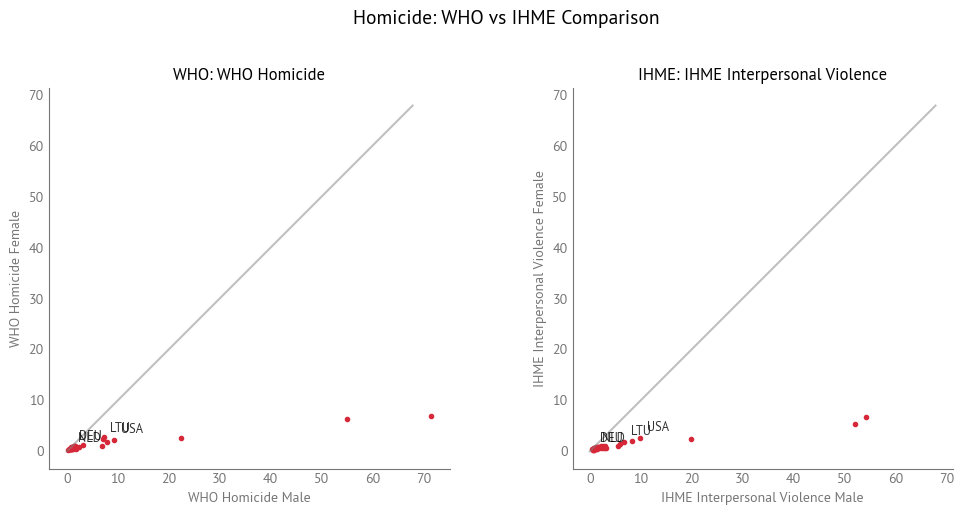

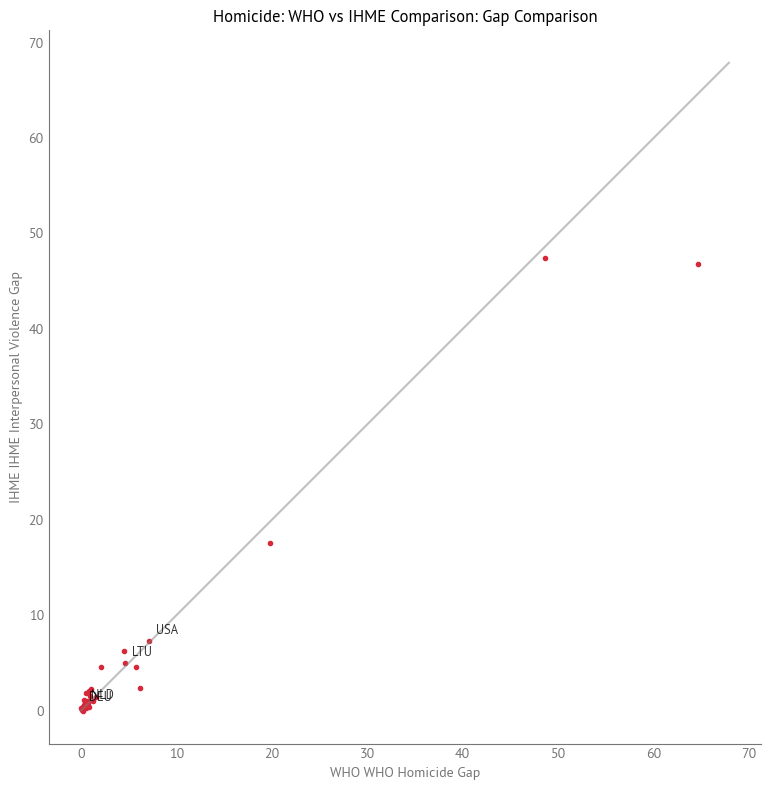

In [117]:
compare_who_ihme(
    homicide_gap, interpersonal_violence_ihme_gap,
    'Gap_Homicide', 'Gap_Homicide',
    'WHO Homicide', 'IHME Interpersonal Violence',
    'Homicide: WHO vs IHME Comparison'
)

### Road Traffic: WHO vs IHME

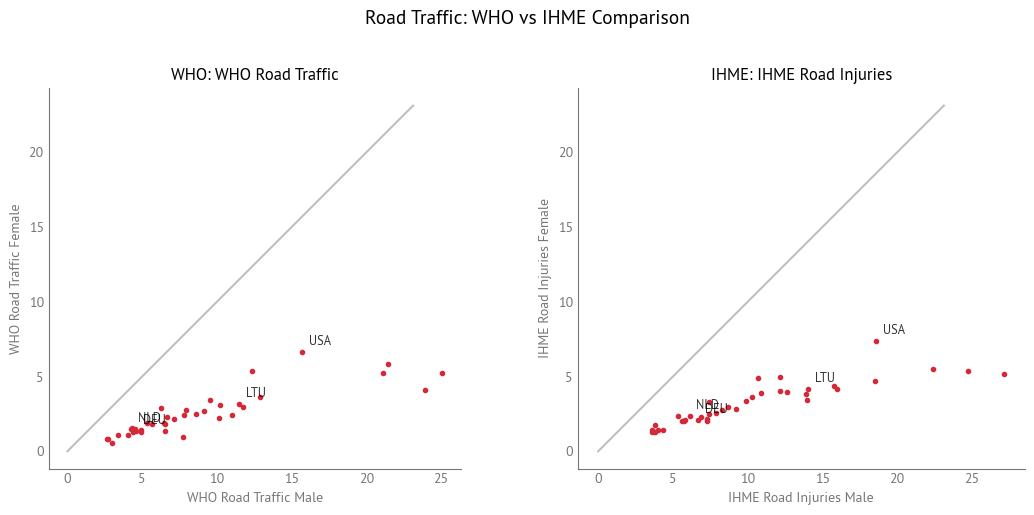

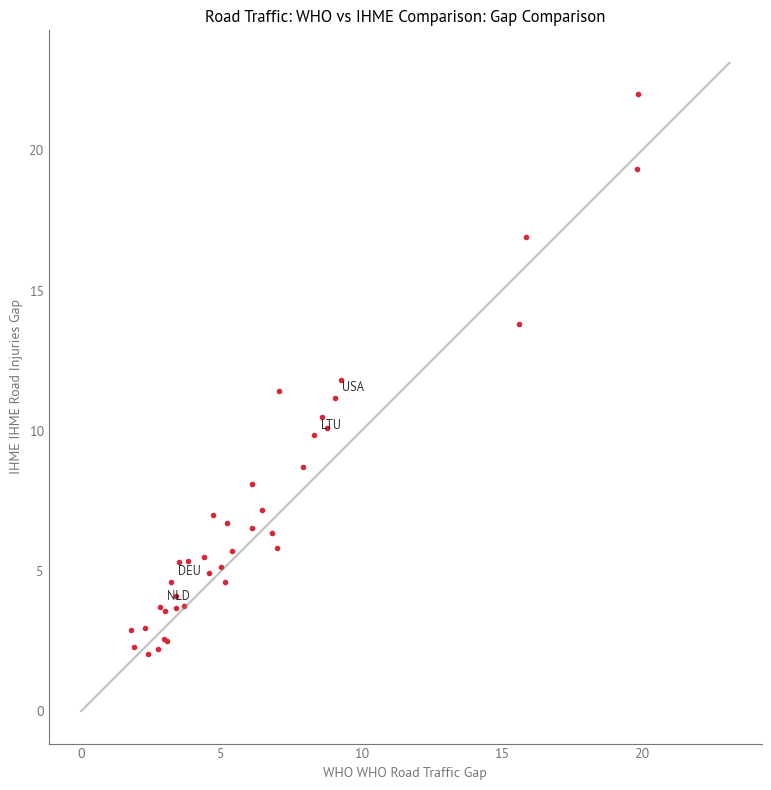

In [118]:
compare_who_ihme(
    traffic_gap, road_injuries_ihme_gap,
    'Gap_RoadTraffic', 'Gap_RoadTraffic',
    'WHO Road Traffic', 'IHME Road Injuries',
    'Road Traffic: WHO vs IHME Comparison'
)

### Poisoning (WHO) vs Drug Disorders (IHME)

Note: These are different concepts (unintentional poisoning vs drug use disorders), but both relate to substance-related mortality.

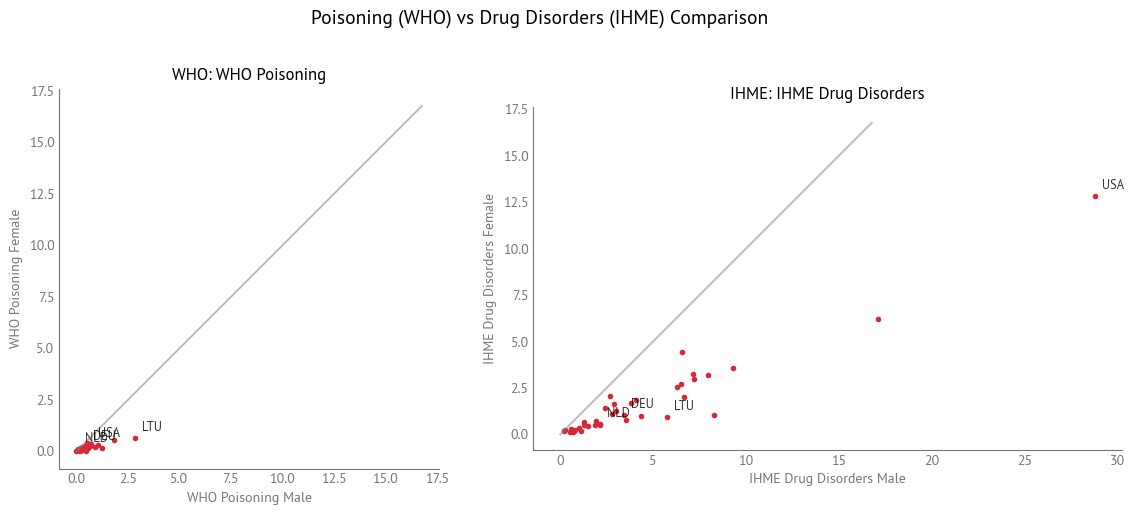

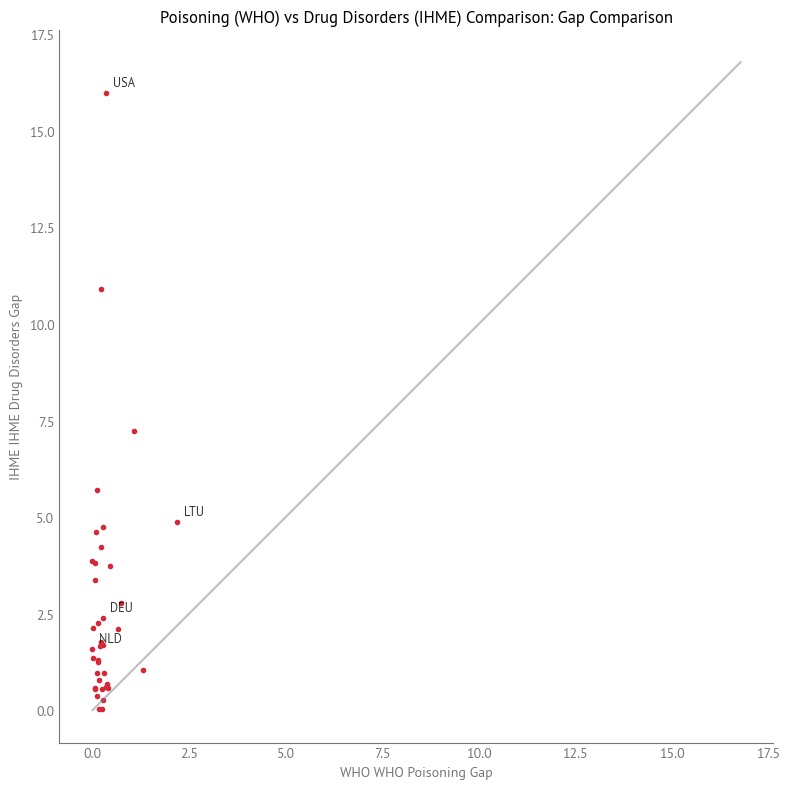

In [119]:
compare_who_ihme(
    poison_gap, drug_disorders_gap,
    'Gap_Poisoning', 'Gap_DrugDisorder',
    'WHO Poisoning', 'IHME Drug Disorders',
    'Poisoning (WHO) vs Drug Disorders (IHME) Comparison'
)

### Under-Five Mortality: WHO vs IHME

Note: WHO measures deaths per 1,000 live births, while IHME measures deaths per 100,000 population. These are different measurement units, so direct comparison of absolute values is not meaningful, but the gender gaps can still be compared.

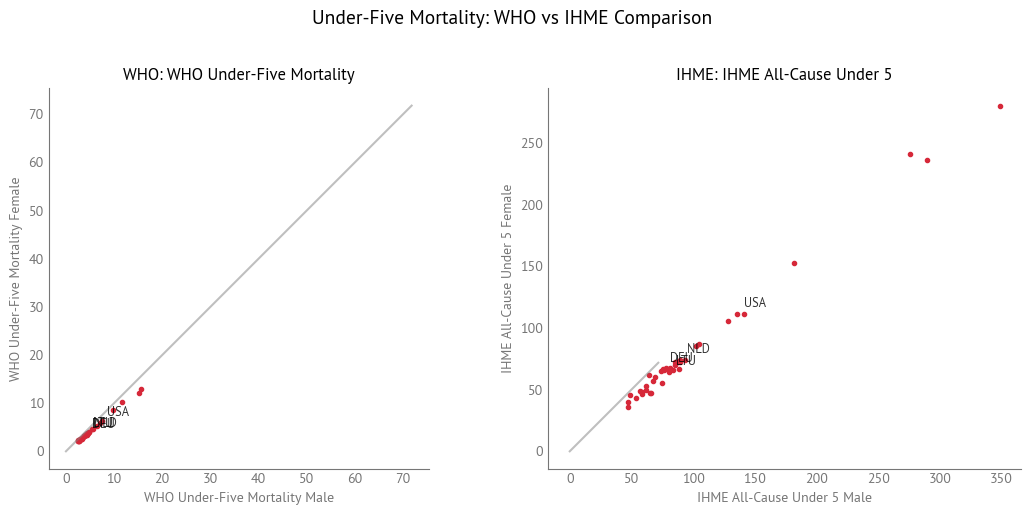

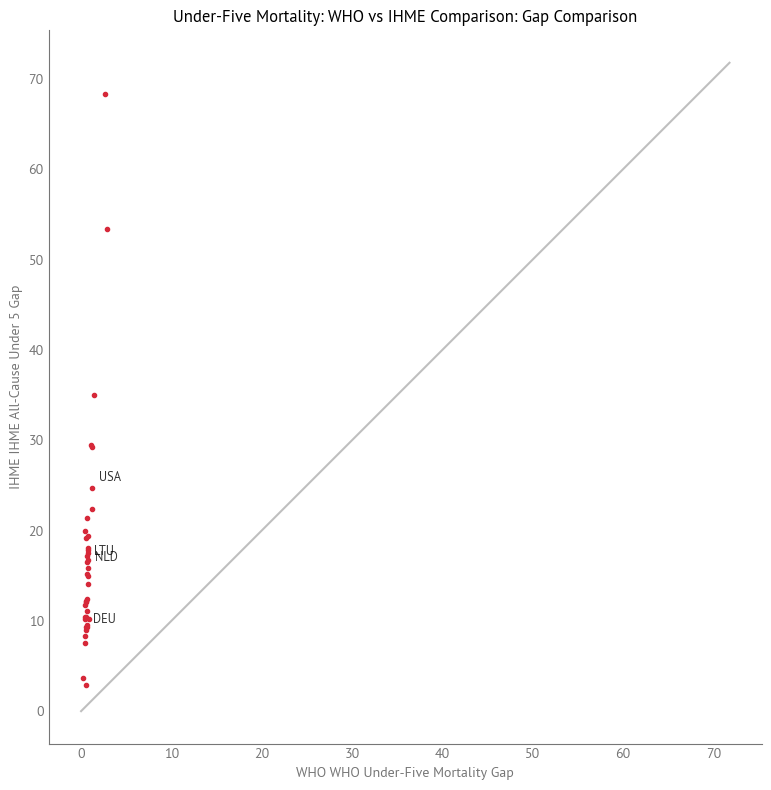

In [120]:
compare_who_ihme(
    u5mr_gap, all_causes_under5_ihme_gap,
    'Gap_Childhood', 'Gap_Childhood',
    'WHO Under-Five Mortality', 'IHME All-Cause Under 5',
    'Under-Five Mortality: WHO vs IHME Comparison'
)

---

## Data Preparation for Regression Analysis

### Prepare Target Variables (HALE and Life Expectancy Gender Gaps)

In [121]:
# Calculate HALE gender gap from existing hale_gap DataFrame
# Gap = Female - Male (positive means females have higher HALE)
hale_gap['HALE_gap'] = hale_gap['HALE_Years_Female'] - hale_gap['HALE_Years_Male']

# Filter to OECD countries
hale_oecd = get_oecd(hale_gap)

# Display summary
hale_oecd[['HALE_Years_Male', 'HALE_Years_Female', 'HALE_gap']].describe()

,HALE_Years_Male,HALE_Years_Female,HALE_gap
count,38.000000,38.000000,38.000000
mean,68.627594,70.605057,1.977462
std,2.533251,1.620032,1.601449
min,63.046587,66.927903,0.018589
25%,66.703502,69.990711,0.870341
50%,69.438269,70.730471,1.385737
75%,70.795272,71.462018,2.923884
max,72.085115,75.013962,6.062020


In [122]:
# Calculate Life Expectancy gender gap from existing le_gap DataFrame
# Gap = Female - Male (positive means females have higher Life Expectancy)
le_gap['LifeExpectancy_gap'] = le_gap['LifeExpectancy_Years_Female'] - le_gap['LifeExpectancy_Years_Male']

# Filter to OECD countries
le_oecd = get_oecd(le_gap)

# Display summary
le_oecd[['LifeExpectancy_Years_Male', 'LifeExpectancy_Years_Female', 'LifeExpectancy_gap']].describe()

,LifeExpectancy_Years_Male,LifeExpectancy_Years_Female,LifeExpectancy_gap
count,38.000000,38.000000,38.000000
mean,78.286623,83.184132,4.897509
std,3.040136,1.914461,1.622577
min,71.050877,78.890552,2.799527
25%,76.360712,82.103078,3.625473
50%,79.469017,83.627520,4.564648
75%,80.680114,84.222983,5.589859
max,81.759398,87.152152,9.361672


### Merge All Predictors into Single Dataset

In [123]:
# Start with HALE and LE
analysis_df = hale_oecd[['HALE_Years_Male', 'HALE_Years_Female', 'HALE_gap']].copy()

analysis_df = analysis_df.join(le_oecd[['LifeExpectancy_Years_Male', 'LifeExpectancy_Years_Female', 'LifeExpectancy_gap']], how='outer')

In [124]:
# Unified mapping from indicator names to complete _gap datasets
# This is the single source of truth for all indicators used in the analysis
indicator_datasets = {
    'Alcohol': alcohol_use_disorders_ihme_gap,  # Using IHME version, renamed to 'Alcohol' via column_name_mapping
    'ChronicRespiratory': chronic_respiratory_ihme_gap,
    'UnintentionalInjury': unintentional_injuries_ihme_gap,
    'RoadTraffic': road_injuries_ihme_gap,  # Using IHME version, renamed to 'RoadTraffic' via column_name_mapping
    'Diabetes': diabetes_ihme_gap,
    'Cardiovascular': cardiovascular_ihme_gap,
    # 'Childhood': all_causes_under5_ihme_gap,  # Removed - low importance and limited temporal coverage. WHO U5MR (per 1,000 live births) is methodologically appropriate but has limited temporal coverage. IHME version (per 100,000 population) is confounded with age structure and fertility.
    'DrugDisorder': drug_disorders_gap,  # Using IHME version, replacing WHO Poisoning
    'Homicide': interpersonal_violence_ihme_gap,  # Using IHME version, renamed to 'Homicide' via column_name_mapping
    # 'Poisoning': poison_gap,  # Removed - using DrugDisorder (IHME) instead
    'Suicide': self_harm_ihme_gap,  # Using IHME version, renamed to 'Suicide' via column_name_mapping
    # 'MaternalMortality': maternal_gap,  # Removed - positive coefficient is suspect (higher female mortality should close gap, not widen it). Likely capturing general healthcare quality with limited variation in rich countries.
    'Neoplasms': neoplasms_ihme_gap,
    'LiverDisease': liver_disease_ihme_gap,  # Using IHME version
}

# Create predictor_dfs by applying OECD filtering to indicator_datasets
# Note: We will exclude Country and Year columns before merging
# We keep Mid (midpoint) and Gap columns as predictors, plus Male/Female columns for counterfactual analysis
predictor_dfs = {name: get_oecd(df) for name, df in indicator_datasets.items()}

In [125]:
# Summary table of year coverage for each indicator
year_summary_df = summarize_years(predictor_dfs)
year_summary_df

,Indicator,Low_Year,High_Year,Most_Common_Year,N_Countries_Most_Common,Total_Countries
0,Alcohol,2019,2019,2019,38,38
1,ChronicRespiratory,2019,2019,2019,38,38
2,UnintentionalInjury,2019,2019,2019,38,38
3,RoadTraffic,2019,2019,2019,38,38
4,Diabetes,2019,2019,2019,38,38
5,Cardiovascular,2019,2019,2019,38,38
6,DrugDisorder,2019,2019,2019,38,38
7,Homicide,2019,2019,2019,38,38
8,Suicide,2019,2019,2019,38,38
9,Neoplasms,2019,2019,2019,38,38


In [126]:
for name, df in predictor_dfs.items():
    drop_cols = ['Country', 'Year']
    # Keep Male, Female, Mid, and Gap columns for counterfactual analysis
    # Only drop Country and Year columns
    if drop_cols:
        predictor_dfs[name] = df.drop(columns=drop_cols)

# Check shapes after dropping Country and Year
for name, predictor_df in predictor_dfs.items():
    print(name, predictor_df.shape)

Alcohol (38, 4)
ChronicRespiratory (38, 4)
UnintentionalInjury (38, 4)
RoadTraffic (38, 4)
Diabetes (38, 4)
Cardiovascular (38, 4)
DrugDisorder (38, 4)
Homicide (38, 4)
Suicide (38, 4)
Neoplasms (38, 4)
LiverDisease (38, 4)


In [127]:
# Merge all predictors on index (Country codes)
for name, df in predictor_dfs.items():
    analysis_df = analysis_df.join(df, how='outer')

# Display shape and column names
analysis_df.shape

(38, 50)

In [128]:
analysis_df.head()

,HALE_Years_Male,HALE_Years_Female,HALE_gap,LifeExpectancy_Years_Male,LifeExpectancy_Years_Female,LifeExpectancy_gap,Alcohol_Male,Alcohol_Female,Gap_Alcohol,Mid_Alcohol,...,Gap_Suicide,Mid_Suicide,Neoplasms_Male,Neoplasms_Female,Gap_Neoplasms,Mid_Neoplasms,LiverDisease_Male,LiverDisease_Female,Gap_LiverDisease,Mid_LiverDisease
Code,,,,,,,,,,,,,,,,,,,,,
AUS,69.678894,70.839417,1.160523,80.720826,84.571060,3.850234,2.959112,0.891430,2.067683,1.925271,...,14.039251,13.573471,243.355910,181.856239,61.499672,212.606075,11.224430,5.733638,5.490792,8.479034
AUT,69.734435,71.097603,1.363167,79.448822,83.776301,4.327479,9.695919,2.007974,7.687945,5.851946,...,17.592919,16.283769,284.168276,237.508863,46.659413,260.838570,26.650674,12.331263,14.319411,19.490969
BEL,69.611904,70.552460,0.940556,79.502396,83.655743,4.153347,6.439571,1.889701,4.549870,4.164636,...,17.352005,18.508852,311.903927,249.263400,62.640527,280.583664,20.162548,11.313553,8.848994,15.738050
CAN,69.657904,70.912614,1.254710,80.124887,83.897128,3.772241,6.291083,1.971652,4.319431,4.131368,...,13.763741,13.045917,264.214805,225.420135,38.794670,244.817470,18.134043,11.014737,7.119306,14.574390
CHE,71.330820,71.668585,0.337766,81.759398,85.115347,3.355950,4.407237,1.434508,2.972729,2.920873,...,12.802890,13.892499,254.475067,210.169723,44.305343,232.322395,12.099416,6.649672,5.449744,9.374544


In [129]:
# Create missing data report
missing_report = pd.DataFrame({
    'Indicator': analysis_df.columns,
    'Missing_Count': [analysis_df[col].isna().sum() for col in analysis_df.columns],
    'Missing_Pct': [analysis_df[col].isna().sum() / len(analysis_df) * 100 for col in analysis_df.columns],
    'Available_Count': [analysis_df[col].notna().sum() for col in analysis_df.columns]
}).sort_values('Missing_Count', ascending=False)

missing_report

,Indicator,Missing_Count,Missing_Pct,Available_Count
0,HALE_Years_Male,0,0.0,38
1,HALE_Years_Female,0,0.0,38
2,HALE_gap,0,0.0,38
3,LifeExpectancy_Years_Male,0,0.0,38
4,LifeExpectancy_Years_Female,0,0.0,38
5,LifeExpectancy_gap,0,0.0,38
6,Alcohol_Male,0,0.0,38
7,Alcohol_Female,0,0.0,38
8,Gap_Alcohol,0,0.0,38
9,Mid_Alcohol,0,0.0,38


In [130]:
# Show which countries have complete data for all indicators
complete_cases = analysis_df.dropna()
complete_cases.shape[0], f"{complete_cases.shape[0] / len(analysis_df) * 100:.1f}% of countries have complete data"

(38, '100.0% of countries have complete data')

### Create Final Analysis Dataset

In [131]:
# Use complete-case analysis for primary model
analysis_complete = analysis_df.dropna()

# Document excluded countries
excluded_countries = set(analysis_df.index) - set(analysis_complete.index)
excluded_countries if excluded_countries else "No countries excluded - all OECD countries have complete data"

'No countries excluded - all OECD countries have complete data'

In [132]:
# Separate target and predictors
# Create both target variables
target_hale = analysis_complete['HALE_gap']
target_le = analysis_complete['LifeExpectancy_gap']
# Keep all predictor columns including Male, Female, Mid, and Gap for counterfactual analysis
# Only drop the target variable columns
predictors = analysis_complete.drop(columns=[
    'HALE_gap', 'HALE_Years_Male', 'HALE_Years_Female',
    'LifeExpectancy_gap', 'LifeExpectancy_Years_Male', 'LifeExpectancy_Years_Female'
])

# Display final dataset info
pd.DataFrame({
    'Dataset': ['Complete Cases'],
    'Countries': [len(analysis_complete)],
    'Target_Variables': ['HALE_gap, LifeExpectancy_gap'],
    'Number_of_Predictors': [len(predictors.columns)],
    'Predictor_Names': [', '.join(predictors.columns)]
})

,Dataset,Countries,Target_Variables,Number_of_Predictors,Predictor_Names
0,Complete Cases,38,"HALE_gap, LifeExpectancy_gap",44,"Alcohol_Male, Alcohol_Female, Gap_Alcohol, Mid..."


## Descriptive Statistics

### HALE Gender Gap 


In [133]:
# Summary statistics for target variable (HALE gap)
target_hale.describe()

count    38.000000
mean      1.977462
std       1.601449
min       0.018589
25%       0.870341
50%       1.385737
75%       2.923884
max       6.062020
Name: HALE_gap, dtype: float64

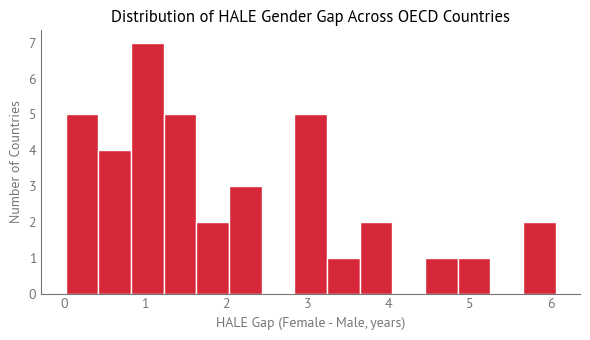

In [134]:
# Distribution of HALE gap across OECD countries
plt.hist(target_hale, bins=15, color=AIBM_COLORS['crimson'], edgecolor='white')
decorate(xlabel='HALE Gap (Female - Male, years)', 
         ylabel='Number of Countries',
         title='Distribution of HALE Gender Gap Across OECD Countries')
plt.savefig('jb/figs/hale_gap_distribution.png', dpi=300, bbox_inches='tight')

In [135]:
# Identify potential outliers using IQR method
Q1 = target_hale.quantile(0.25)
Q3 = target_hale.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = target_hale[(target_hale < lower_bound) | (target_hale > upper_bound)]
outliers_df = pd.DataFrame({
    'Country': outliers.index,
    'HALE_Gap': outliers.values
}).sort_values('HALE_Gap')

outliers_df if not outliers_df.empty else "No outliers detected using IQR method"

,Country,HALE_Gap
0,LTU,6.06202


### Life Expectancy Gender Gap 


In [136]:
# Summary statistics for target variable (Life Expectancy gap)
target_le.describe()

count    38.000000
mean      4.897509
std       1.622577
min       2.799527
25%       3.625473
50%       4.564648
75%       5.589859
max       9.361672
Name: LifeExpectancy_gap, dtype: float64

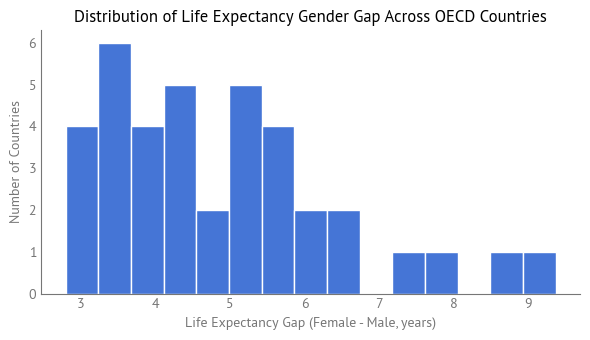

In [137]:
# Distribution of Life Expectancy gap across OECD countries
plt.hist(target_le, bins=15, color=AIBM_COLORS['blue'], edgecolor='white')
decorate(xlabel='Life Expectancy Gap (Female - Male, years)', 
         ylabel='Number of Countries',
         title='Distribution of Life Expectancy Gender Gap Across OECD Countries')
plt.savefig('jb/figs/life_expectancy_gap_distribution.png', dpi=300, bbox_inches='tight')

In [138]:
# Identify potential outliers using IQR method
Q1 = target_le.quantile(0.25)
Q3 = target_le.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = target_le[(target_le < lower_bound) | (target_le > upper_bound)]
outliers_df = pd.DataFrame({
    'Country': outliers.index,
    'LifeExpectancy_Gap': outliers.values
}).sort_values('LifeExpectancy_Gap')

outliers_df if not outliers_df.empty else "No outliers detected using IQR method"

,Country,LifeExpectancy_Gap
1,LVA,8.919780
0,LTU,9.361672


### Comparison of HALE and Life Expectancy Gaps

In [139]:
# Compare the two target variables
comparison_df = pd.DataFrame({
    'HALE_Gap': target_hale,
    'LifeExpectancy_Gap': target_le
})

comparison_df.describe()

,HALE_Gap,LifeExpectancy_Gap
count,38.000000,38.000000
mean,1.977462,4.897509
std,1.601449,1.622577
min,0.018589,2.799527
25%,0.870341,3.625473
50%,1.385737,4.564648
75%,2.923884,5.589859
max,6.062020,9.361672


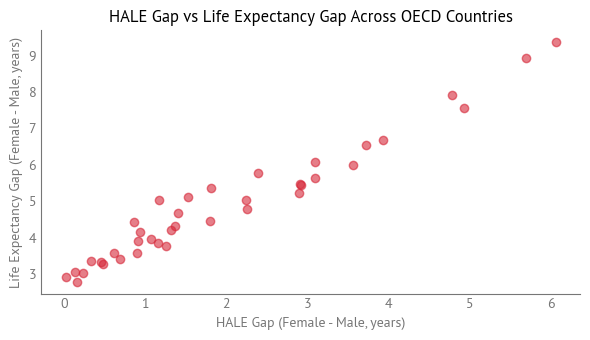

In [140]:
# Scatter plot comparing HALE gap vs Life Expectancy gap
plt.scatter(target_hale, target_le, color=AIBM_COLORS['crimson'], alpha=0.6)
decorate(xlabel='HALE Gap (Female - Male, years)', 
         ylabel='Life Expectancy Gap (Female - Male, years)',
         title='HALE Gap vs Life Expectancy Gap Across OECD Countries')
plt.savefig('jb/figs/hale_vs_le_gap_comparison.png', dpi=300, bbox_inches='tight')

In [141]:
# Correlation between the two target variables
correlation = target_hale.corr(target_le)
print(f"Correlation between HALE gap and Life Expectancy gap: {correlation:.3f}")

Correlation between HALE gap and Life Expectancy gap: 0.975


### Extreme Values and Country Rankings

In [142]:
# Get list of indicators from indicator_datasets
indicator_names = list(indicator_datasets.keys())

# Create tables for each indicator showing top 5 and bottom 5 countries
indicator_extremes = {}

for indicator_name in indicator_names:
    # Get the dataframe directly from indicator_datasets
    df_gap = indicator_datasets[indicator_name]
    
    # Find Male and Female columns dynamically (they end with _Male or _Female)
    male_cols = [col for col in df_gap.columns if col.endswith('_Male')]
    female_cols = [col for col in df_gap.columns if col.endswith('_Female')]
    
    # Get the base name from the first male column (remove _Male suffix)
    if male_cols and female_cols:
        # Use the first matching pair
        male_col = male_cols[0]
        female_col = female_cols[0]
        # Verify they have the same base name
        base_name_male = male_col[:-5]  # Remove '_Male'
        base_name_female = female_col[:-7]  # Remove '_Female'
        if base_name_male == base_name_female:
            # Create summary for this indicator
            indicator_data = df_gap[[male_col, female_col]].copy()
            indicator_data['Country'] = df_gap['Country']
            
            # For male values
            male_sorted = indicator_data.sort_values(male_col, ascending=False)
            male_top5 = male_sorted.head(5)[['Country', male_col]].copy()
            male_bottom5 = male_sorted.tail(5)[['Country', male_col]].copy()
            
            # For female values
            female_sorted = indicator_data.sort_values(female_col, ascending=False)
            female_top5 = female_sorted.head(5)[['Country', female_col]].copy()
            female_bottom5 = female_sorted.tail(5)[['Country', female_col]].copy()
            
            indicator_extremes[indicator_name] = {
                'male_top5': male_top5,
                'male_bottom5': male_bottom5,
                'female_top5': female_top5,
                'female_bottom5': female_bottom5
            }

# Display results for a few key indicators
key_indicators = ['Alcohol', 'Homicide', 'Cardiovascular', 'Suicide']
for indicator in key_indicators:
    if indicator in indicator_extremes:
        print(f"\n{'='*60}")
        print(f"{indicator} - Extreme Values")
        print(f"{'='*60}")
        print(f"\nTop 5 Countries - Male Values:")
        display(indicator_extremes[indicator]['male_top5'])
        print(f"\nBottom 5 Countries - Male Values:")
        display(indicator_extremes[indicator]['male_bottom5'])
        print(f"\nTop 5 Countries - Female Values:")
        display(indicator_extremes[indicator]['female_top5'])
        print(f"\nBottom 5 Countries - Female Values:")
        display(indicator_extremes[indicator]['female_bottom5'])


Alcohol - Extreme Values

Top 5 Countries - Male Values:


,Country,Alcohol_Male
Code,,
SVN,Slovenia,26.825015
POL,Poland,25.369577
EST,Estonia,22.315092
LVA,Latvia,17.815870
LTU,Lithuania,16.446870



Bottom 5 Countries - Male Values:


,Country,Alcohol_Male
Code,,
ITA,Italy,1.054543
GRC,Greece,0.951413
JPN,Japan,0.930056
TUR,Türkiye,0.598283
COL,Colombia,0.345757



Top 5 Countries - Female Values:


...

,Country,Suicide_Male
Code,,
MEX,Mexico,10.911529
COL,Colombia,10.708033
ISR,Israel,9.137919
GRC,Greece,8.151591
TUR,Türkiye,6.455776



Top 5 Countries - Female Values:


,Country,Suicide_Female
Code,,
KOR,South Korea,15.328136
JPN,Japan,10.576004
BEL,Belgium,9.832849
LTU,Lithuania,9.377562
SWE,Sweden,8.708172



Bottom 5 Countries - Female Values:


,Country,Suicide_Female
Code,,
COL,Colombia,2.564868
MEX,Mexico,2.418808
ISR,Israel,2.389282
TUR,Türkiye,1.945029
GRC,Greece,1.780707


#### For Gender Gaps: Largest and Smallest Gaps

In [143]:
gap_extremes = {}

for indicator_name in indicator_names:
    # Get the dataframe directly from indicator_datasets
    df_gap = indicator_datasets[indicator_name]
    
    # Find columns dynamically
    gap_cols = [col for col in df_gap.columns if col.startswith('Gap_')]
    male_cols = [col for col in df_gap.columns if col.endswith('_Male')]
    female_cols = [col for col in df_gap.columns if col.endswith('_Female')]
    
    # Find matching columns (same base name)
    if gap_cols and male_cols and female_cols:
        # Get the base name from the gap column (remove 'Gap_' prefix)
        gap_col = gap_cols[0]
        base_name = gap_col[4:]  # Remove 'Gap_' prefix
        
        # Find matching male and female columns
        male_col = f'{base_name}_Male'
        female_col = f'{base_name}_Female'
        
        if male_col in df_gap.columns and female_col in df_gap.columns:
            # Create summary with country names
            gap_data = df_gap[[male_col, female_col, gap_col]].copy()
            gap_data['Country'] = df_gap['Country']
            
            # Sort by gap (largest positive gaps first)
            # Note: Gap is computed as Male - Female, so positive means males have higher rates
            gap_sorted = gap_data.sort_values(gap_col, ascending=False)
            
            gap_top5 = gap_sorted.head(5).copy()
            gap_bottom5 = gap_sorted.tail(5).copy()
            
            gap_extremes[indicator_name] = {
                'top5': gap_top5,
                'bottom5': gap_bottom5
            }

# Display results for key indicators
for indicator in key_indicators:
    if indicator in gap_extremes:
        print(f"\n{'='*60}")
        print(f"{indicator} - Gender Gap Extremes (Male - Female)")
        print(f"{'='*60}")
        gap_info = gap_extremes[indicator]
        # Get column names dynamically from the DataFrame
        top5_df = gap_info['top5']
        # Find Male, Female, and Gap columns
        male_col = [col for col in top5_df.columns if col.endswith('_Male')][0] if any(col.endswith('_Male') for col in top5_df.columns) else None
        female_col = [col for col in top5_df.columns if col.endswith('_Female')][0] if any(col.endswith('_Female') for col in top5_df.columns) else None
        gap_col = [col for col in top5_df.columns if col.startswith('Gap_')][0] if any(col.startswith('Gap_') for col in top5_df.columns) else None
        
        cols_to_show = ['Country']
        if male_col:
            cols_to_show.append(male_col)
        if female_col:
            cols_to_show.append(female_col)
        if gap_col:
            cols_to_show.append(gap_col)
        
        print(f"\nTop 5 Countries - Largest Gaps (Male > Female):")
        display(gap_info['top5'][cols_to_show])
        print(f"\nBottom 5 Countries - Smallest Gaps (Female > Male):")
        display(gap_info['bottom5'][cols_to_show])


Alcohol - Gender Gap Extremes (Male - Female)

Top 5 Countries - Largest Gaps (Male > Female):


,Country,Alcohol_Male,Alcohol_Female,Gap_Alcohol
Code,,,,
SVN,Slovenia,26.825015,3.225022,23.599994
POL,Poland,25.369577,3.436546,21.933031
EST,Estonia,22.315092,3.870510,18.444583
LVA,Latvia,17.815870,3.036423,14.779447
LTU,Lithuania,16.446870,3.680546,12.766324



Bottom 5 Countries - Smallest Gaps (Female > Male):


,Country,Alcohol_Male,Alcohol_Female,Gap_Alcohol
Code,,,,
ITA,Italy,1.054543,0.200089,0.854454
GRC,Greece,0.951413,0.112198,0.839215
JPN,Japan,0.930056,0.111777,0.818278
TUR,Türkiye,0.598283,0.033294,0.564989
COL,Colombia,0.345757,0.040256,0.305501



Homicide - Gender Gap Extremes (Male - Female)

Top 5 Countries - Largest Gaps (Male > Female):


...

,Country,Cardiovascular_Male,Cardiovascular_Female,Gap_Cardiovascular
Code,,,,
HUN,Hungary,594.432143,665.433915,-71.001772
LTU,Lithuania,701.266757,790.639377,-89.372620
SVN,Slovenia,298.249378,410.684804,-112.435426
EST,Estonia,459.136591,581.214309,-122.077718
LVA,Latvia,679.916500,803.819385,-123.902885



Suicide - Gender Gap Extremes (Male - Female)

Top 5 Countries - Largest Gaps (Male > Female):


,Country,Suicide_Male,Suicide_Female,Gap_Suicide
Code,,,,
LTU,Lithuania,49.529743,9.377562,40.152181
LVA,Latvia,32.172092,6.511077,25.661016
POL,Poland,28.218716,3.877572,24.341144
KOR,South Korea,38.082623,15.328136,22.754488
SVN,Slovenia,29.043521,6.862732,22.180789



Bottom 5 Countries - Smallest Gaps (Female > Male):


,Country,Suicide_Male,Suicide_Female,Gap_Suicide
Code,,,,
COL,Colombia,10.708033,2.564868,8.143165
ITA,Italy,11.033287,2.946616,8.086671
ISR,Israel,9.137919,2.389282,6.748637
GRC,Greece,8.151591,1.780707,6.370884
TUR,Türkiye,6.455776,1.945029,4.510746


#### For HALE Gap: All Countries Ranked

In [144]:
# Create ranked table of all countries by HALE gap
hale_ranked = analysis_complete[['HALE_Years_Male', 'HALE_Years_Female', 'HALE_gap']].copy()
hale_ranked = hale_ranked.sort_values('HALE_gap', ascending=False).reset_index()
hale_ranked['Rank'] = range(1, len(hale_ranked) + 1)
# Rename: Country (code) -> Code, add Country (name)
hale_ranked = hale_ranked.rename(columns={'Country': 'Code'})
hale_ranked['Country'] = hale_ranked['Code'].map(code_to_who_country)

# Create output version without Rank column (Rank kept internally for comparison table)
hale_ranked_output = hale_ranked[['Country', 'HALE_Years_Male', 
                                   'HALE_Years_Female', 'HALE_gap']].copy()

print("All Countries Ranked by HALE Gap (Female - Male)")
print("="*80)
hale_ranked_output

All Countries Ranked by HALE Gap (Female - Male)


,Country,HALE_Years_Male,HALE_Years_Female,HALE_gap
0,Lithuania,63.104683,69.166703,6.062020
1,Latvia,63.046587,68.738555,5.691968
2,Poland,65.084376,70.014177,4.929800
3,Estonia,65.801117,70.591652,4.790534
4,Slovakia,65.475856,69.406819,3.930964
5,Hungary,64.668835,68.391010,3.722175
6,South Korea,70.624330,74.188925,3.564595
7,Mexico,63.922174,67.017593,3.095419
8,Czechia,66.923801,70.014838,3.091037
9,Japan,72.085115,75.013962,2.928847


In [145]:
# Write HALE gap by country table to HTML (without Rank column)
write_html_table(hale_ranked_output, f"jb/tables/hale_gap_by_country_{cutoff_year}.html")

In [146]:
# Summary statistics for HALE gap
print("\nHALE Gap Summary Statistics:")
print("="*50)
print(f"Mean HALE Gap: {hale_ranked['HALE_gap'].mean():.2f} years")
print(f"Median HALE Gap: {hale_ranked['HALE_gap'].median():.2f} years")
print(f"Standard Deviation: {hale_ranked['HALE_gap'].std():.2f} years")
print(f"Range: {hale_ranked['HALE_gap'].min():.2f} to {hale_ranked['HALE_gap'].max():.2f} years")
print(f"\nCountries with Largest HALE Gap (Top 5):")
hale_ranked_output.head(5)
print(f"\nCountries with Smallest HALE Gap (Bottom 5):")
hale_ranked_output.tail(5)


HALE Gap Summary Statistics:
Mean HALE Gap: 1.98 years
Median HALE Gap: 1.39 years
Standard Deviation: 1.60 years
Range: 0.02 to 6.06 years

Countries with Largest HALE Gap (Top 5):

Countries with Smallest HALE Gap (Bottom 5):


,Country,HALE_Years_Male,HALE_Years_Female,HALE_gap
33,Switzerland,71.330820,71.668585,0.337766
34,Norway,71.042668,71.281402,0.238734
35,Iceland,71.302050,71.462248,0.160198
36,Sweden,71.327303,71.461329,0.134025
37,Netherlands,71.052035,71.070623,0.018589


#### For Life Expectancy Gap: All Countries Ranked

In [147]:
# Create ranked table of all countries by Life Expectancy gap
le_ranked = analysis_complete[['LifeExpectancy_Years_Male', 'LifeExpectancy_Years_Female', 'LifeExpectancy_gap']].copy()
le_ranked = le_ranked.sort_values('LifeExpectancy_gap', ascending=False).reset_index()
le_ranked['Rank'] = range(1, len(le_ranked) + 1)
# Rename: Country (code) -> Code, add Country (name)
le_ranked = le_ranked.rename(columns={'Country': 'Code'})
le_ranked['Country'] = le_ranked['Code'].map(code_to_who_country)

# Create output version without Rank column (Rank kept internally for comparison table)
le_ranked_output = le_ranked[['Country', 'LifeExpectancy_Years_Male', 
                              'LifeExpectancy_Years_Female', 'LifeExpectancy_gap']].copy()

print("All Countries Ranked by Life Expectancy Gap (Female - Male)")
print("="*80)
le_ranked_output

All Countries Ranked by Life Expectancy Gap (Female - Male)


,Country,LifeExpectancy_Years_Male,LifeExpectancy_Years_Female,LifeExpectancy_gap
0,Lithuania,71.453559,80.815232,9.361672
1,Latvia,71.050877,79.970658,8.919780
2,Estonia,74.694832,82.613621,7.918789
3,Poland,73.942241,81.496925,7.554684
4,Slovakia,74.232903,80.903401,6.670498
5,Hungary,72.982508,79.524351,6.541844
6,Mexico,72.800400,78.890552,6.090152
7,South Korea,80.557979,86.564637,6.006658
8,Portugal,78.378969,84.149594,5.770625
9,Czechia,76.303106,81.932897,5.629791


In [148]:
# Write Life Expectancy gap by country table to HTML (without Rank column)
write_html_table(le_ranked_output, f"jb/tables/le_gap_by_country_{cutoff_year}.html")

In [149]:
# Summary statistics for Life Expectancy gap
print("\nLife Expectancy Gap Summary Statistics:")
print("="*50)
print(f"Mean Life Expectancy Gap: {le_ranked['LifeExpectancy_gap'].mean():.2f} years")
print(f"Median Life Expectancy Gap: {le_ranked['LifeExpectancy_gap'].median():.2f} years")
print(f"Standard Deviation: {le_ranked['LifeExpectancy_gap'].std():.2f} years")
print(f"Range: {le_ranked['LifeExpectancy_gap'].min():.2f} to {le_ranked['LifeExpectancy_gap'].max():.2f} years")
print(f"\nCountries with Largest Life Expectancy Gap (Top 5):")
le_ranked_output.head(5)
print(f"\nCountries with Smallest Life Expectancy Gap (Bottom 5):")
le_ranked_output.tail(5)


Life Expectancy Gap Summary Statistics:
Mean Life Expectancy Gap: 4.90 years
Median Life Expectancy Gap: 4.56 years
Standard Deviation: 1.62 years
Range: 2.80 to 9.36 years

Countries with Largest Life Expectancy Gap (Top 5):

Countries with Smallest Life Expectancy Gap (Bottom 5):


,Country,LifeExpectancy_Years_Male,LifeExpectancy_Years_Female,LifeExpectancy_gap
33,New Zealand,80.160434,83.431491,3.271057
34,Sweden,81.167954,84.242571,3.074617
35,Norway,81.123682,84.164216,3.040535
36,Netherlands,80.845218,83.760027,2.914809
37,Iceland,81.100922,83.900450,2.799527


### Summary Statistics by Indicator

In [150]:
# Create summary table with rate and gap statistics for each indicator
def compute_indicator_stats(indicator_name, df_gap):
    """Compute statistics for a single indicator."""
    # Get OECD countries only for consistency
    df_oecd = get_oecd(df_gap)
    
    # Find Mid and Gap columns dynamically
    mid_cols = [col for col in df_gap.columns if col.startswith('Mid_')]
    gap_cols = [col for col in df_gap.columns if col.startswith('Gap_')]
    
    # Handle normal case: indicators with both Mid and Gap columns
    if mid_cols and gap_cols:
        mid_col = mid_cols[0]
        gap_col = gap_cols[0]
        
        # Extract midpoint and gap values
        midpoints = df_oecd[mid_col].dropna()
        gaps = df_oecd[gap_col].dropna()
        
        if len(midpoints) > 0 and len(gaps) > 0:
            return {
                'Indicator': indicator_name,
                'Median Rate': midpoints.median(),
                'Min Rate': midpoints.min(),
                'Max Rate': midpoints.max(),
                'Median Gap': gaps.median(),
                'Min Gap': gaps.min(),
                'Max Gap': gaps.max()
            }
    
    # Handle special case: MaternalMortality (female-only, no Gap/Mid columns)
    # Use the Female value as both midpoint and gap
    elif indicator_name == 'MaternalMortality':
        female_cols = [col for col in df_gap.columns if col.endswith('_Female')]
        if female_cols:
            female_col = female_cols[0]
            values = df_oecd[female_col].dropna()
            
            if len(values) > 0:
                return {
                    'Indicator': indicator_name,
                    'Median Rate': values.median(),
                    'Min Rate': values.min(),
                    'Max Rate': values.max(),
                    'Median Gap': -values.median(),
                    'Min Gap': -values.min(),
                    'Max Gap': -values.max()
                }
    
    return None

In [151]:
# Process predictor indicators
predictor_summary = []
for indicator_name, df_gap in indicator_datasets.items():
    stats = compute_indicator_stats(indicator_name, df_gap)
    if stats:
        predictor_summary.append(stats)

# Process target variables
target_summary = []
target_indicators = {
    'HALE': hale_gap,
    'Life Expectancy': le_gap
}
for indicator_name, df_gap in target_indicators.items():
    stats = compute_indicator_stats(indicator_name, df_gap)
    if stats:
        target_summary.append(stats)

In [152]:
# Create DataFrames (keep Indicator as a column, not index)
predictor_df = pd.DataFrame(predictor_summary)
target_df = pd.DataFrame(target_summary)

# Split predictor table into rates and gaps
predictor_rates = predictor_df[['Indicator', 'Median Rate', 'Min Rate', 'Max Rate']].copy()
predictor_gaps = predictor_df[['Indicator', 'Median Gap', 'Min Gap', 'Max Gap']].copy()

# Calculate correlations with target variables
# For rates: use Mid_ columns, for gaps: use Gap_ columns
# Special case: MaternalMortality uses Female column for both
predictor_rates['Corr HALE'] = np.nan
predictor_rates['Corr LE'] = np.nan
predictor_gaps['Corr HALE'] = np.nan
predictor_gaps['Corr LE'] = np.nan

for idx, indicator in enumerate(predictor_rates['Indicator']):
    if indicator == 'MaternalMortality':
        # MaternalMortality: use Female column for both rates and gaps (if present)
        female_col = 'MaternalMortality_Female'
        if female_col in predictors.columns:
            predictor_rates.loc[idx, 'Corr HALE'] = predictors[female_col].corr(target_hale)
            predictor_rates.loc[idx, 'Corr LE'] = predictors[female_col].corr(target_le)
            predictor_gaps.loc[idx, 'Corr HALE'] = predictors[female_col].corr(target_hale)
            predictor_gaps.loc[idx, 'Corr LE'] = predictors[female_col].corr(target_le)
        else:
            # MaternalMortality not in predictors, skip correlation calculation
            predictor_rates.loc[idx, 'Corr HALE'] = np.nan
            predictor_rates.loc[idx, 'Corr LE'] = np.nan
            predictor_gaps.loc[idx, 'Corr HALE'] = np.nan
            predictor_gaps.loc[idx, 'Corr LE'] = np.nan
    else:
        # Find the corresponding Mid_ and Gap_ columns in predictors DataFrame
        mid_col = f'Mid_{indicator}'
        gap_col = f'Gap_{indicator}'
        
        # Calculate correlations for rates (using Mid_ columns)
        if mid_col in predictors.columns:
            predictor_rates.loc[idx, 'Corr HALE'] = predictors[mid_col].corr(target_hale)
            predictor_rates.loc[idx, 'Corr LE'] = predictors[mid_col].corr(target_le)
        else:
            predictor_rates.loc[idx, 'Corr HALE'] = np.nan
            predictor_rates.loc[idx, 'Corr LE'] = np.nan
        
        # Calculate correlations for gaps (using Gap_ columns)
        if gap_col in predictors.columns:
            predictor_gaps.loc[idx, 'Corr HALE'] = predictors[gap_col].corr(target_hale)
            predictor_gaps.loc[idx, 'Corr LE'] = predictors[gap_col].corr(target_le)
        else:
            predictor_gaps.loc[idx, 'Corr HALE'] = np.nan
            predictor_gaps.loc[idx, 'Corr LE'] = np.nan

# Split target table into rates and gaps, reverse gap signs, and adjust column names
target_rates = target_df[['Indicator', 'Median Rate', 'Min Rate', 'Max Rate']].copy()
target_rates.columns = ['Indicator', 'Median', 'Min', 'Max']
target_gaps = target_df[['Indicator', 'Median Gap', 'Min Gap', 'Max Gap']].copy()
# Reverse sign of gaps (from Male - Female to Female - Male)
target_gaps['Median Gap'] = -target_gaps['Median Gap']
target_gaps['Min Gap'] = -target_gaps['Min Gap']
target_gaps['Max Gap'] = -target_gaps['Max Gap']
# After negation, min and max are swapped, so swap the column values
target_gaps['Min Gap'], target_gaps['Max Gap'] = target_gaps['Max Gap'], target_gaps['Min Gap']
target_gaps.columns = ['Indicator', 'Median Gap', 'Min Gap', 'Max Gap']

In [153]:
print("Predictor Indicators - Rates:")
predictor_rates = predictor_rates.sort_values(by='Median Rate', ascending=False).reset_index(drop=True)
predictor_rates

Predictor Indicators - Rates:


,Indicator,Median Rate,Min Rate,Max Rate,Corr HALE,Corr LE
0,Neoplasms,265.079065,80.284321,365.434048,0.213639,0.228070
1,Cardiovascular,240.639346,112.887107,745.953067,0.688936,0.721275
2,ChronicRespiratory,43.715973,17.076192,85.409818,-0.536548,-0.517093
3,UnintentionalInjury,26.490283,10.701691,46.386257,0.219734,0.259305
4,Diabetes,18.492425,7.398758,60.993339,0.338293,0.376996
5,LiverDisease,15.466523,3.092065,36.498128,0.733636,0.740414
6,Suicide,13.044885,4.200403,29.453652,0.537512,0.511444
7,RoadTraffic,5.680746,2.456672,16.162382,0.444781,0.417968
8,Alcohol,3.093621,0.193006,15.025019,0.559049,0.545402
9,DrugDisorder,2.136641,0.211947,20.827363,-0.194022,-0.232498


In [154]:
print("Predictor Indicators - Gaps:")
predictor_gaps = predictor_gaps.sort_values(by='Median Gap', ascending=False).reset_index(drop=True)
predictor_gaps

Predictor Indicators - Gaps:


,Indicator,Median Gap,Min Gap,Max Gap,Corr HALE,Corr LE
0,Neoplasms,57.601876,-0.787975,131.660360,0.454026,0.519367
1,Suicide,13.790887,4.510746,40.152181,0.748291,0.733134
2,LiverDisease,9.652243,1.287206,32.554825,0.724059,0.732500
3,ChronicRespiratory,8.032934,-19.339710,34.055132,0.474996,0.550337
4,RoadTraffic,5.604407,2.037390,22.025433,0.419930,0.402382
5,UnintentionalInjury,4.947472,-11.173752,37.064721,0.832806,0.848433
6,Alcohol,3.572909,0.305501,23.599994,0.618174,0.601937
7,DrugDisorder,1.662612,0.022645,15.976720,-0.063586,-0.093205
8,Homicide,0.887375,-0.062157,47.465542,0.233029,0.190169
9,Diabetes,-0.173252,-9.828557,5.500981,-0.478383,-0.564071


In [155]:
print("Target Variables - Rates:")
target_rates.sort_values(by='Median', ascending=False).reset_index(drop=True)

Target Variables - Rates:


,Indicator,Median,Min,Max
0,Life Expectancy,81.440590,75.510767,84.427418
1,HALE,70.124757,65.469884,73.549538


In [156]:
print("Target Variables - Gaps:")
target_gaps

Target Variables - Gaps:


,Indicator,Median Gap,Min Gap,Max Gap
0,HALE,1.385737,0.018589,6.062020
1,Life Expectancy,4.564648,2.799527,9.361672


In [157]:
write_html_table(predictor_rates, f"jb/tables/predictor_rates_{cutoff_year}.html")
write_html_table(predictor_gaps,  f"jb/tables/predictor_gaps_{cutoff_year}.html")

write_html_table(target_rates,    f"jb/tables/target_rates_{cutoff_year}.html")
write_html_table(target_gaps,     f"jb/tables/target_gaps_{cutoff_year}.html")

In [158]:
# Create table showing correlation between Rate (Mid) and Gap for each indicator
rate_gap_correlations = []

for indicator in predictor_rates['Indicator']:
    # Skip MaternalMortality - it doesn't have a Gap column (female-only)
    if indicator == 'MaternalMortality':
        continue
    
    # Find the corresponding Mid_ and Gap_ columns in predictors DataFrame
    rate_col = f'Mid_{indicator}'
    gap_col = f'Gap_{indicator}'
    
    # Calculate correlation between rate and gap
    if rate_col in predictors.columns and gap_col in predictors.columns:
        corr = predictors[rate_col].corr(predictors[gap_col])
        rate_gap_correlations.append({
            'Indicator': indicator,
            'Correlation': corr
        })

# Create DataFrame and format (keep Indicator as a column)
rate_gap_corr_df = pd.DataFrame(rate_gap_correlations)

# Sort by correlation (descending)
rate_gap_corr_df = rate_gap_corr_df.sort_values('Correlation', ascending=False).reset_index(drop=True)

In [159]:
write_html_table(rate_gap_corr_df, f"jb/tables/rate_gap_correlation_{cutoff_year}.html")

In [160]:
# Create table showing top 10 correlations between rates (Mid columns)
# Get all Mid_ columns
mid_cols = [col for col in predictors.columns if col.startswith('Mid_')]

# Calculate correlation matrix for rates
rates_corr_matrix = predictors[mid_cols].corr()

# Extract upper triangle (excluding diagonal) and convert to list of pairs
rates_corr_pairs = []
for i in range(len(rates_corr_matrix.columns)):
    for j in range(i+1, len(rates_corr_matrix.columns)):
        indicator1 = rates_corr_matrix.columns[i].replace('Mid_', '')
        indicator2 = rates_corr_matrix.columns[j].replace('Mid_', '')
        corr_val = rates_corr_matrix.iloc[i, j]
        rates_corr_pairs.append({
            'Rate 1': indicator1,
            'Rate 2': indicator2,
            'Correlation': corr_val
        })

# Create DataFrame and sort by absolute correlation
rates_corr_df = pd.DataFrame(rates_corr_pairs)
rates_corr_df['Abs Correlation'] = rates_corr_df['Correlation'].abs()
rates_corr_df = rates_corr_df.sort_values('Abs Correlation', ascending=False).head(10)

# Drop the absolute value column
rates_corr_df = rates_corr_df[['Rate 1', 'Rate 2', 'Correlation']].reset_index(drop=True)

In [161]:
write_html_table(rates_corr_df,     f"jb/tables/rate_rate_correlation_top10_{cutoff_year}.html")

In [162]:
# Create table showing top 10 correlations between gaps (Gap columns)
# Get all Gap_ columns (excluding MaternalMortality which doesn't have a Gap column)
gap_cols = [col for col in predictors.columns if col.startswith('Gap_')]

# Calculate correlation matrix for gaps
gaps_corr_matrix = predictors[gap_cols].corr()

# Extract upper triangle (excluding diagonal) and convert to list of pairs
gaps_corr_pairs = []
for i in range(len(gaps_corr_matrix.columns)):
    for j in range(i+1, len(gaps_corr_matrix.columns)):
        indicator1 = gaps_corr_matrix.columns[i].replace('Gap_', '')
        indicator2 = gaps_corr_matrix.columns[j].replace('Gap_', '')
        corr_val = gaps_corr_matrix.iloc[i, j]
        gaps_corr_pairs.append({
            'Gap 1': indicator1,
            'Gap 2': indicator2,
            'Correlation': corr_val
        })

# Create DataFrame and sort by absolute correlation
gaps_corr_df = pd.DataFrame(gaps_corr_pairs)
gaps_corr_df['Abs Correlation'] = gaps_corr_df['Correlation'].abs()
gaps_corr_df = gaps_corr_df.sort_values('Abs Correlation', ascending=False).head(10)

# Drop the absolute value column
gaps_corr_df = gaps_corr_df[['Gap 1', 'Gap 2', 'Correlation']].reset_index(drop=True)

In [163]:
write_html_table(gaps_corr_df,     f"jb/tables/gap_gap_correlation_top10_{cutoff_year}.html")

### Save Data for Future Use

In [164]:
# Save to HDF5 file
hdf_file = f'../data/hale_analysis_data_{cutoff_year}.h5'
with pd.HDFStore(hdf_file, mode='w') as store:
    store['predictors'] = predictors
    store['target_hale'] = target_hale
    store['target_le'] = target_le

In [165]:
predictors.columns

Index(['Alcohol_Male', 'Alcohol_Female', 'Gap_Alcohol', 'Mid_Alcohol',
       'ChronicRespiratory_Male', 'ChronicRespiratory_Female',
       'Gap_ChronicRespiratory', 'Mid_ChronicRespiratory',
       'UnintentionalInjury_Male', 'UnintentionalInjury_Female',
       'Gap_UnintentionalInjury', 'Mid_UnintentionalInjury',
       'RoadTraffic_Male', 'RoadTraffic_Female', 'Gap_RoadTraffic',
       'Mid_RoadTraffic', 'Diabetes_Male', 'Diabetes_Female', 'Gap_Diabetes',
       'Mid_Diabetes', 'Cardiovascular_Male', 'Cardiovascular_Female',
       'Gap_Cardiovascular', 'Mid_Cardiovascular', 'DrugDisorder_Male',
       'DrugDisorder_Female', 'Gap_DrugDisorder', 'Mid_DrugDisorder',
       'Homicide_Male', 'Homicide_Female', 'Gap_Homicide', 'Mid_Homicide',
       'Suicide_Male', 'Suicide_Female', 'Gap_Suicide', 'Mid_Suicide',
       'Neoplasms_Male', 'Neoplasms_Female', 'Gap_Neoplasms', 'Mid_Neoplasms',
       'LiverDisease_Male', 'LiverDisease_Female', 'Gap_LiverDisease',
       'Mid_LiverDisease']

In [166]:
from utils import beep

beep()